# 07 - Evaluation and Ablation Study

Phase 7 consolidates **headline final-track** metrics (`phase5_weighted_blend`, CNN sequence, XGB/LGBM raw) and keeps PCA/PSO rows as diagnostic references.

Two operating modes must be reported:

- **Balanced:** validation max Macro F1 (τ=0.30 for seed 42 weighted blend).
- **Precision-first:** Precision Fake ≥ 97.5% when feasible, then max Recall Fake / Macro F1 (τ=0.60).

SSOT probabilities: `artifacts/predictions/phase5_weighted_blend_*_prob.npy`. Phase 6 XAI pointers prefer `phase6_final_*` outputs.


## How to run on Colab

1. Run notebooks 01-05 and **`06_Adversarial_XAI.ipynb`** (final-track XAI), then sync the project folder to Google Drive.
2. Confirm `phase5_weighted_blend_*_prob.npy`, `phase5_xgb_raw_*_prob.npy`, and `phase6_final_metadata.json` exist.
3. Run this notebook top-to-bottom.
4. Legacy PCA probabilities (`xgboost_*`, `dl_pso_*`) are optional diagnostic rows when artifacts are present.


In [1]:
# try/except: khối xử lý ngoại lệ
try:
    # import google.colab  # type: ignore: import thư viện google
    import google.colab  # type: ignore
# except: xử lý ngoại lệ — except ImportError as exc:
except ImportError as exc:
    # raise RuntimeError(: ném lỗi và dừng cell
    raise RuntimeError(
        # "Run this notebook in Google Colab. Local execution is disabled by project polic...: thực thi lệnh Python
        "Run this notebook in Google Colab. Local execution is disabled by project policy."
    # ) from exc: thực thi lệnh Python
    ) from exc


In [2]:
# from google.colab import drive: import thư viện google
from google.colab import drive

# drive.mount("/content/drive"): mount Google Drive trên Colab
drive.mount("/content/drive")


Mounted at /content/drive


In [3]:
# import gc: giải phóng bộ nhớ
import gc
# import importlib: import thư viện importlib
import importlib
# import json: đọc/ghi JSON metadata
import json
# import os: biến môi trường hệ thống
import os
# import platform: import thư viện platform
import platform
# import random: cố định seed ngẫu nhiên
import random
# import subprocess: chạy lệnh pip/cài package
import subprocess
# import sys: tham số Python runtime
import sys
# import time: đo thời gian thực thi
import time
# from datetime import datetime, timezone: import thư viện datetime
from datetime import datetime, timezone
# from pathlib import Path: quản lý đường dẫn
from pathlib import Path
# from typing import Any: import thư viện typing
from typing import Any


# ensure_package: import hoặc pip install package
def ensure_package(import_name: str, pip_name: str | None = None):
    # try/except: khối xử lý ngoại lệ
    try:
        # return: trả kết quả từ hàm
        return importlib.import_module(import_name)
    # except: xử lý ngoại lệ — except ImportError:
    except ImportError:
        # subprocess.check_call([sys.executable, "-m", "pip", "install", pip_name or impor...: thực thi lệnh Python
        subprocess.check_call([sys.executable, "-m", "pip", "install", pip_name or import_name])
        # return: trả kết quả từ hàm
        return importlib.import_module(import_name)


# joblib = ...: gán giá trị cho biến joblib
joblib = ensure_package("joblib")
# lightgbm = ...: gán giá trị cho biến lightgbm
lightgbm = ensure_package("lightgbm")

# import matplotlib.pyplot: vẽ biểu đồ
import matplotlib.pyplot as plt
# import numpy: tính toán mảng số
import numpy as np
# import pandas: xử lý DataFrame
import pandas as pd
# from lightgbm import LGBMClassifier: thư viện LightGBM
from lightgbm import LGBMClassifier
# from sklearn.decomposition import PCA, TruncatedSVD: thư viện machine learning scikit-learn
from sklearn.decomposition import PCA, TruncatedSVD
# from sklearn.linear_model import LogisticRegression: thư viện machine learning scikit-learn
from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import (: thư viện machine learning scikit-learn
from sklearn.metrics import (
    # accuracy_score,: thực thi lệnh Python
    accuracy_score,
    # average_precision_score,: thực thi lệnh Python
    average_precision_score,
    # brier_score_loss,: thực thi lệnh Python
    brier_score_loss,
    # confusion_matrix,: thực thi lệnh Python
    confusion_matrix,
    # f1_score,: thực thi lệnh Python
    f1_score,
    # precision_recall_fscore_support,: thực thi lệnh Python
    precision_recall_fscore_support,
    # roc_auc_score,: thực thi lệnh Python
    roc_auc_score,
# ): đóng ngoặc gọi hàm
)
# from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit: thư viện machine learning scikit-learn
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
# from sklearn.preprocessing import StandardScaler: thư viện machine learning scikit-learn
from sklearn.preprocessing import StandardScaler

# print("Python:", sys.version): in thông tin ra console
print("Python:", sys.version)
# print("Platform:", platform.platform()): in thông tin ra console
print("Platform:", platform.platform())
# print("numpy:", np.__version__): in thông tin ra console
print("numpy:", np.__version__)
# print("pandas:", pd.__version__): in thông tin ra console
print("pandas:", pd.__version__)
# print("lightgbm:", lightgbm.__version__): in thông tin ra console
print("lightgbm:", lightgbm.__version__)


Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Platform: Linux-6.6.122+-x86_64-with-glibc2.35
numpy: 2.0.2
pandas: 2.2.2
lightgbm: 4.6.0


In [4]:
# SEED: biến cấu hình/hằng số của notebook
SEED = 42
# FAKE_LABEL: biến cấu hình/hằng số của notebook
FAKE_LABEL = 1
# REAL_LABEL: biến cấu hình/hằng số của notebook
REAL_LABEL = 0
# DEFAULT_THRESHOLD: biến cấu hình/hằng số của notebook
DEFAULT_THRESHOLD = 0.50
# TARGET_METRICS: biến cấu hình/hằng số của notebook
TARGET_METRICS = {"macro_f1": 0.89, "precision_fake": 0.975, "roc_auc": 0.93}

# CV_FOLDS: biến cấu hình/hằng số của notebook
CV_FOLDS = 5
# CV_MAX_ROWS: biến cấu hình/hằng số của notebook
CV_MAX_ROWS = None
# CV_RUN_LIGHTGBM: biến cấu hình/hằng số của notebook
CV_RUN_LIGHTGBM = True
# CV_RUN_LOGISTIC_BASELINE: biến cấu hình/hằng số của notebook
CV_RUN_LOGISTIC_BASELINE = False
# CONTROLLED_ABLATION_MAX_ROWS: biến cấu hình/hằng số của notebook
CONTROLLED_ABLATION_MAX_ROWS = None
# CONTROLLED_ABLATION_REDUCED_DIM: biến cấu hình/hằng số của notebook
CONTROLLED_ABLATION_REDUCED_DIM = 400
# CONTROLLED_MEMORY_LIMIT_MB: biến cấu hình/hằng số của notebook
CONTROLLED_MEMORY_LIMIT_MB = 2500
# RUN_CONTROLLED_ABLATIONS: biến cấu hình/hằng số của notebook
RUN_CONTROLLED_ABLATIONS = True

# PROJECT_ROOT_CANDIDATES: biến cấu hình/hằng số của notebook
PROJECT_ROOT_CANDIDATES = [
    # Path(os.environ.get("FAKE_REVIEWS_PROJECT_ROOT", "")) if os.environ.get("FAKE_RE...: thực thi lệnh Python
    Path(os.environ.get("FAKE_REVIEWS_PROJECT_ROOT", "")) if os.environ.get("FAKE_REVIEWS_PROJECT_ROOT") else None,
    # Path("/content/drive/MyDrive/BaoMatCuoiKy/Fake_reviews"),: thực thi lệnh Python
    Path("/content/drive/MyDrive/BaoMatCuoiKy/Fake_reviews"),
    # Path("/content/drive/MyDrive/Fake_reviews"),: thực thi lệnh Python
    Path("/content/drive/MyDrive/Fake_reviews"),
# ]: đóng khối danh sách
]
# PROJECT_ROOT: biến cấu hình/hằng số của notebook
PROJECT_ROOT = next((path for path in PROJECT_ROOT_CANDIDATES if path is not None and path.exists()), None)
# if: điều kiện — if PROJECT_ROOT is None:
if PROJECT_ROOT is None:
    # candidates = ...: ép kiểu chuỗi
    candidates = [str(path) for path in PROJECT_ROOT_CANDIDATES if path is not None]
    # raise FileNotFoundError(f"Could not locate project root. Tried: {candidates}"): ném lỗi và dừng cell
    raise FileNotFoundError(f"Could not locate project root. Tried: {candidates}")

# ARTIFACT_DIR: biến cấu hình/hằng số của notebook
ARTIFACT_DIR = PROJECT_ROOT / "artifacts"
# FEATURE_DIR: biến cấu hình/hằng số của notebook
FEATURE_DIR = ARTIFACT_DIR / "features"
# PCA_DIR: biến cấu hình/hằng số của notebook
PCA_DIR = ARTIFACT_DIR / "pca"
# MODEL_DIR: biến cấu hình/hằng số của notebook
MODEL_DIR = ARTIFACT_DIR / "models"
# ENSEMBLE_DIR: biến cấu hình/hằng số của notebook
ENSEMBLE_DIR = ARTIFACT_DIR / "ensemble"
# PREDICTION_DIR: biến cấu hình/hằng số của notebook
PREDICTION_DIR = ARTIFACT_DIR / "predictions"
# EVALUATION_DIR: biến cấu hình/hằng số của notebook
EVALUATION_DIR = ARTIFACT_DIR / "evaluation"
# XAI_DIR: biến cấu hình/hằng số của notebook
XAI_DIR = ARTIFACT_DIR / "xai"
# REPORT_TABLE_DIR: biến cấu hình/hằng số của notebook
REPORT_TABLE_DIR = PROJECT_ROOT / "reports" / "tables"
# REPORT_FIGURE_DIR: biến cấu hình/hằng số của notebook
REPORT_FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"
# DATA_PROCESSED_DIR: biến cấu hình/hằng số của notebook
DATA_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

# for: vòng lặp — for directory in [EVALUATION_DIR, REPORT_TABLE_DIR, REPORT_F
for directory in [EVALUATION_DIR, REPORT_TABLE_DIR, REPORT_FIGURE_DIR]:
    # directory.mkdir(parents=True, exist_ok=True): tạo thư mục nếu chưa có
    directory.mkdir(parents=True, exist_ok=True)


# seed_everything: cố định seed Python/numpy/torch
def seed_everything(seed: int = SEED) -> None:
    # random.seed(seed): cố định seed random
    random.seed(seed)
    # os.environ["PYTHONHASHSEED"] = str(seed): ép kiểu chuỗi
    os.environ["PYTHONHASHSEED"] = str(seed)
    # np.random.seed(seed): cố định seed numpy
    np.random.seed(seed)


# utc_now: định nghĩa hàm utc now
def utc_now() -> str:
    # return: trả kết quả từ hàm
    return datetime.now(timezone.utc).isoformat()


# read_json: đọc file JSON
def read_json(path: Path) -> dict[str, Any]:
    # with: context manager — with path.open("r", encoding="utf-8") as file:
    with path.open("r", encoding="utf-8") as file:
        # return: parse nội dung JSON
        return json.load(file)


# environment_versions: hàm xử lý environment versions
def environment_versions() -> dict[str, Any]:
    # return: trả kết quả từ hàm
    return {
        # "python": sys.version,: thực thi lệnh Python
        "python": sys.version,
        # "platform": platform.platform(),: thực thi lệnh Python
        "platform": platform.platform(),
        # "numpy": np.__version__,: thực thi lệnh Python
        "numpy": np.__version__,
        # "pandas": pd.__version__,: thực thi lệnh Python
        "pandas": pd.__version__,
        # "sklearn": importlib.import_module("sklearn").__version__,: thực thi lệnh Python
        "sklearn": importlib.import_module("sklearn").__version__,
        # "lightgbm": lightgbm.__version__,: thực thi lệnh Python
        "lightgbm": lightgbm.__version__,
    # }: đóng khối từ điển
    }


# seed_everything(SEED): thực thi lệnh Python
seed_everything(SEED)
# PHASE7_FALLBACKS: list[dict[str, Any]] = []: chuyển/chiếu thành list
PHASE7_FALLBACKS: list[dict[str, Any]] = []
# print("Project root:", PROJECT_ROOT): in thông tin ra console
print("Project root:", PROJECT_ROOT)


Project root: /content/drive/MyDrive/BaoMatCuoiKy/Fake_reviews


In [5]:
# PCA_FEATURE_PATHS: biến cấu hình/hằng số của notebook
PCA_FEATURE_PATHS = {
    # "train": PCA_DIR / "features_final_train.npy",: thực thi lệnh Python
    "train": PCA_DIR / "features_final_train.npy",
    # "val": PCA_DIR / "features_final_val.npy",: thực thi lệnh Python
    "val": PCA_DIR / "features_final_val.npy",
    # "test": PCA_DIR / "features_final_test.npy",: thực thi lệnh Python
    "test": PCA_DIR / "features_final_test.npy",
# }: đóng khối từ điển
}
# PCA_LABEL_PATHS: biến cấu hình/hằng số của notebook
PCA_LABEL_PATHS = {
    # "train": PCA_DIR / "labels_train.npy",: thực thi lệnh Python
    "train": PCA_DIR / "labels_train.npy",
    # "val": PCA_DIR / "labels_val.npy",: thực thi lệnh Python
    "val": PCA_DIR / "labels_val.npy",
    # "test": PCA_DIR / "labels_test.npy",: thực thi lệnh Python
    "test": PCA_DIR / "labels_test.npy",
# }: đóng khối từ điển
}
# RAW_FEATURE_PATHS: biến cấu hình/hằng số của notebook
RAW_FEATURE_PATHS = {
    # "train": FEATURE_DIR / "features_raw_train.npy",: thực thi lệnh Python
    "train": FEATURE_DIR / "features_raw_train.npy",
    # "val": FEATURE_DIR / "features_raw_val.npy",: thực thi lệnh Python
    "val": FEATURE_DIR / "features_raw_val.npy",
    # "test": FEATURE_DIR / "features_raw_test.npy",: thực thi lệnh Python
    "test": FEATURE_DIR / "features_raw_test.npy",
# }: đóng khối từ điển
}
# RAW_LABEL_PATHS: biến cấu hình/hằng số của notebook
RAW_LABEL_PATHS = {
    # "train": FEATURE_DIR / "labels_train.npy",: thực thi lệnh Python
    "train": FEATURE_DIR / "labels_train.npy",
    # "val": FEATURE_DIR / "labels_val.npy",: thực thi lệnh Python
    "val": FEATURE_DIR / "labels_val.npy",
    # "test": FEATURE_DIR / "labels_test.npy",: thực thi lệnh Python
    "test": FEATURE_DIR / "labels_test.npy",
# }: đóng khối từ điển
}
# ROW_ID_PATHS: biến cấu hình/hằng số của notebook
ROW_ID_PATHS = {
    # "train": FEATURE_DIR / "row_ids_train.csv",: thực thi lệnh Python
    "train": FEATURE_DIR / "row_ids_train.csv",
    # "val": FEATURE_DIR / "row_ids_val.csv",: thực thi lệnh Python
    "val": FEATURE_DIR / "row_ids_val.csv",
    # "test": FEATURE_DIR / "row_ids_test.csv",: thực thi lệnh Python
    "test": FEATURE_DIR / "row_ids_test.csv",
# }: đóng khối từ điển
}
# PROBABILITY_PATHS: biến cấu hình/hằng số của notebook
PROBABILITY_PATHS = {
    # "dl_baseline": {: thực thi lệnh Python
    "dl_baseline": {
        # "train": PREDICTION_DIR / "dl_baseline_train_prob.npy",: thực thi lệnh Python
        "train": PREDICTION_DIR / "dl_baseline_train_prob.npy",
        # "val": PREDICTION_DIR / "dl_baseline_val_prob.npy",: thực thi lệnh Python
        "val": PREDICTION_DIR / "dl_baseline_val_prob.npy",
        # "test": PREDICTION_DIR / "dl_baseline_test_prob.npy",: thực thi lệnh Python
        "test": PREDICTION_DIR / "dl_baseline_test_prob.npy",
    # },: đóng phần tử từ điển (còn phần tử sau)
    },
    # "dl_pso": {: thực thi lệnh Python
    "dl_pso": {
        # "train": PREDICTION_DIR / "dl_pso_train_prob.npy",: thực thi lệnh Python
        "train": PREDICTION_DIR / "dl_pso_train_prob.npy",
        # "val": PREDICTION_DIR / "dl_pso_val_prob.npy",: thực thi lệnh Python
        "val": PREDICTION_DIR / "dl_pso_val_prob.npy",
        # "test": PREDICTION_DIR / "dl_pso_test_prob.npy",: thực thi lệnh Python
        "test": PREDICTION_DIR / "dl_pso_test_prob.npy",
    # },: đóng phần tử từ điển (còn phần tử sau)
    },
    # "xgboost": {: thực thi lệnh Python
    "xgboost": {
        # "train": PREDICTION_DIR / "xgboost_train_prob.npy",: thực thi lệnh Python
        "train": PREDICTION_DIR / "xgboost_train_prob.npy",
        # "val": PREDICTION_DIR / "xgboost_val_prob.npy",: thực thi lệnh Python
        "val": PREDICTION_DIR / "xgboost_val_prob.npy",
        # "test": PREDICTION_DIR / "xgboost_test_prob.npy",: thực thi lệnh Python
        "test": PREDICTION_DIR / "xgboost_test_prob.npy",
    # },: đóng phần tử từ điển (còn phần tử sau)
    },
    # "lightgbm": {: thực thi lệnh Python
    "lightgbm": {
        # "train": PREDICTION_DIR / "lightgbm_train_prob.npy",: thực thi lệnh Python
        "train": PREDICTION_DIR / "lightgbm_train_prob.npy",
        # "val": PREDICTION_DIR / "lightgbm_val_prob.npy",: thực thi lệnh Python
        "val": PREDICTION_DIR / "lightgbm_val_prob.npy",
        # "test": PREDICTION_DIR / "lightgbm_test_prob.npy",: thực thi lệnh Python
        "test": PREDICTION_DIR / "lightgbm_test_prob.npy",
    # },: đóng phần tử từ điển (còn phần tử sau)
    },
    # "stacking": {: thực thi lệnh Python
    "stacking": {
        # "train": PREDICTION_DIR / "stacking_train_prob.npy",: thực thi lệnh Python
        "train": PREDICTION_DIR / "stacking_train_prob.npy",
        # "val": PREDICTION_DIR / "stacking_val_prob.npy",: thực thi lệnh Python
        "val": PREDICTION_DIR / "stacking_val_prob.npy",
        # "test": PREDICTION_DIR / "stacking_test_prob.npy",: thực thi lệnh Python
        "test": PREDICTION_DIR / "stacking_test_prob.npy",
    # },: đóng phần tử từ điển (còn phần tử sau)
    },
    # "phase5_weighted_blend": {: đếm số phần tử
    "phase5_weighted_blend": {
        # "train": PREDICTION_DIR / "phase5_weighted_blend_train_prob.npy",: đếm số phần tử
        "train": PREDICTION_DIR / "phase5_weighted_blend_train_prob.npy",
        # "val": PREDICTION_DIR / "phase5_weighted_blend_val_prob.npy",: đếm số phần tử
        "val": PREDICTION_DIR / "phase5_weighted_blend_val_prob.npy",
        # "test": PREDICTION_DIR / "phase5_weighted_blend_test_prob.npy",: đếm số phần tử
        "test": PREDICTION_DIR / "phase5_weighted_blend_test_prob.npy",
    # },: đóng phần tử từ điển (còn phần tử sau)
    },
    # "phase5_xgb_raw": {: thực thi lệnh Python
    "phase5_xgb_raw": {
        # "train": PREDICTION_DIR / "phase5_xgb_raw_train_prob.npy",: thực thi lệnh Python
        "train": PREDICTION_DIR / "phase5_xgb_raw_train_prob.npy",
        # "val": PREDICTION_DIR / "phase5_xgb_raw_val_prob.npy",: thực thi lệnh Python
        "val": PREDICTION_DIR / "phase5_xgb_raw_val_prob.npy",
        # "test": PREDICTION_DIR / "phase5_xgb_raw_test_prob.npy",: thực thi lệnh Python
        "test": PREDICTION_DIR / "phase5_xgb_raw_test_prob.npy",
    # },: đóng phần tử từ điển (còn phần tử sau)
    },
    # "phase5_lgbm_raw": {: thực thi lệnh Python
    "phase5_lgbm_raw": {
        # "train": PREDICTION_DIR / "phase5_lgbm_raw_train_prob.npy",: thực thi lệnh Python
        "train": PREDICTION_DIR / "phase5_lgbm_raw_train_prob.npy",
        # "val": PREDICTION_DIR / "phase5_lgbm_raw_val_prob.npy",: thực thi lệnh Python
        "val": PREDICTION_DIR / "phase5_lgbm_raw_val_prob.npy",
        # "test": PREDICTION_DIR / "phase5_lgbm_raw_test_prob.npy",: thực thi lệnh Python
        "test": PREDICTION_DIR / "phase5_lgbm_raw_test_prob.npy",
    # },: đóng phần tử từ điển (còn phần tử sau)
    },
    # "phase5_mlp_raw": {: thực thi lệnh Python
    "phase5_mlp_raw": {
        # "train": PREDICTION_DIR / "phase5_mlp_raw_train_prob.npy",: thực thi lệnh Python
        "train": PREDICTION_DIR / "phase5_mlp_raw_train_prob.npy",
        # "val": PREDICTION_DIR / "phase5_mlp_raw_val_prob.npy",: thực thi lệnh Python
        "val": PREDICTION_DIR / "phase5_mlp_raw_val_prob.npy",
        # "test": PREDICTION_DIR / "phase5_mlp_raw_test_prob.npy",: thực thi lệnh Python
        "test": PREDICTION_DIR / "phase5_mlp_raw_test_prob.npy",
    # },: đóng phần tử từ điển (còn phần tử sau)
    },
    # "phase5_cnn_bilstm_sequence": {: thực thi lệnh Python
    "phase5_cnn_bilstm_sequence": {
        # "train": PREDICTION_DIR / "phase5_cnn_bilstm_sequence_train_prob.npy",: thực thi lệnh Python
        "train": PREDICTION_DIR / "phase5_cnn_bilstm_sequence_train_prob.npy",
        # "val": PREDICTION_DIR / "phase5_cnn_bilstm_sequence_val_prob.npy",: thực thi lệnh Python
        "val": PREDICTION_DIR / "phase5_cnn_bilstm_sequence_val_prob.npy",
        # "test": PREDICTION_DIR / "phase5_cnn_bilstm_sequence_test_prob.npy",: thực thi lệnh Python
        "test": PREDICTION_DIR / "phase5_cnn_bilstm_sequence_test_prob.npy",
    # },: đóng phần tử từ điển (còn phần tử sau)
    },
# }: đóng khối từ điển
}

# PHASE2_METADATA_PATH: biến cấu hình/hằng số của notebook
PHASE2_METADATA_PATH = FEATURE_DIR / "feature_metadata.json"
# FEATURE_DICTIONARY_PATH: biến cấu hình/hằng số của notebook
FEATURE_DICTIONARY_PATH = FEATURE_DIR / "feature_dictionary.csv"
# PCA_REDUCER_PATH: biến cấu hình/hằng số của notebook
PCA_REDUCER_PATH = PCA_DIR / "pca_or_svd.joblib"
# PCA_SCALER_PATH: biến cấu hình/hằng số của notebook
PCA_SCALER_PATH = PCA_DIR / "pca_scaler.joblib"
# PHASE3_METADATA_PATH: biến cấu hình/hằng số của notebook
PHASE3_METADATA_PATH = PCA_DIR / "phase3_metadata.json"
# PHASE4_METADATA_PATH: biến cấu hình/hằng số của notebook
PHASE4_METADATA_PATH = MODEL_DIR / "phase4_metadata.json"
# PHASE5_METADATA_PATH: biến cấu hình/hằng số của notebook
PHASE5_METADATA_PATH = ENSEMBLE_DIR / "phase5_metadata.json"
# PHASE5_WEIGHTED_BLEND_METADATA_PATH: biến cấu hình/hằng số của notebook
PHASE5_WEIGHTED_BLEND_METADATA_PATH = ENSEMBLE_DIR / "phase5_weighted_blend_metadata.json" # Added missing definition
# PHASE6_METADATA_PATH: biến cấu hình/hằng số của notebook
PHASE6_METADATA_PATH = XAI_DIR / "phase6_metadata.json"
# PHASE6_FINAL_METADATA_PATH: biến cấu hình/hằng số của notebook
PHASE6_FINAL_METADATA_PATH = XAI_DIR / "phase6_final_metadata.json"

# PHASE4_BASELINE_METRICS_PATH: biến cấu hình/hằng số của notebook
PHASE4_BASELINE_METRICS_PATH = REPORT_TABLE_DIR / "phase4_baseline_metrics.csv"
# PHASE4_PSO_METRICS_PATH: biến cấu hình/hằng số của notebook
PHASE4_PSO_METRICS_PATH = REPORT_TABLE_DIR / "phase4_pso_final_metrics.csv"
# PHASE5_BASE_METRICS_PATH: biến cấu hình/hằng số của notebook
PHASE5_BASE_METRICS_PATH = REPORT_TABLE_DIR / "phase5_base_model_metrics.csv"
# PHASE5_STACKING_METRICS_PATH: biến cấu hình/hằng số của notebook
PHASE5_STACKING_METRICS_PATH = REPORT_TABLE_DIR / "phase5_stacking_metrics.csv"
# PHASE5_FINAL_METRICS_PATH: biến cấu hình/hằng số của notebook
PHASE5_FINAL_METRICS_PATH = REPORT_TABLE_DIR / "phase5_final_metrics.csv"
# PHASE5_CANDIDATE_SELECTION_PATH: biến cấu hình/hằng số của notebook
PHASE5_CANDIDATE_SELECTION_PATH = REPORT_TABLE_DIR / "phase5_candidate_selection.csv"
# PHASE5_CANDIDATE_THRESHOLD_PATH: biến cấu hình/hằng số của notebook
PHASE5_CANDIDATE_THRESHOLD_PATH = REPORT_TABLE_DIR / "phase5_candidate_threshold_report.csv"
# PHASE5_SELECTED_THRESHOLD_PATH: biến cấu hình/hằng số của notebook
PHASE5_SELECTED_THRESHOLD_PATH = REPORT_TABLE_DIR / "phase5_selected_threshold.csv"
# PHASE5_LEADERBOARD_PATH: biến cấu hình/hằng số của notebook
PHASE5_LEADERBOARD_PATH = REPORT_TABLE_DIR / "phase5_leaderboard.csv"
# PHASE5_SELECTED_CANDIDATES_PATH: biến cấu hình/hằng số của notebook
PHASE5_SELECTED_CANDIDATES_PATH = REPORT_TABLE_DIR / "phase5_selected_candidates.csv"
# PHASE5_TEST_AUDIT_PATH: biến cấu hình/hằng số của notebook
PHASE5_TEST_AUDIT_PATH = REPORT_TABLE_DIR / "phase5_selected_candidates_test_audit.csv"
# PHASE6_ROBUSTNESS_PATH: biến cấu hình/hằng số của notebook
PHASE6_ROBUSTNESS_PATH = REPORT_TABLE_DIR / "phase6_robustness_metrics.csv"
# PHASE6_SHAP_IMPORTANCE_PATH: biến cấu hình/hằng số của notebook
PHASE6_SHAP_IMPORTANCE_PATH = REPORT_TABLE_DIR / "phase6_shap_global_importance.csv"
# PHASE6_LIME_CASES_PATH: biến cấu hình/hằng số của notebook
PHASE6_LIME_CASES_PATH = REPORT_TABLE_DIR / "phase6_lime_case_summary.csv"


## 1. Validate Phase 2-6 Inputs

This preflight records every artifact the notebook expects and fails early if any required artifact is missing. It only checks file metadata and array shapes.

In [6]:
# npy_shape_dtype: hàm xử lý npy shape dtype
def npy_shape_dtype(path: Path) -> tuple[str | None, str | None, float | None]:
    # if: điều kiện — if not path.exists():
    if not path.exists():
        # return: trả kết quả từ hàm
        return None, None, None
    # arr = ...: nạp mảng từ file .npy
    arr = np.load(path, mmap_mode="r")
    # memory_mb = ...: ép kiểu số thực
    memory_mb = float(np.prod(arr.shape) * arr.dtype.itemsize / (1024**2))
    # return: trả kết quả từ hàm
    return str(tuple(arr.shape)), str(arr.dtype), memory_mb


# csv_rows: hàm xử lý csv rows
def csv_rows(path: Path) -> int | None:
    # if: điều kiện — if not path.exists():
    if not path.exists():
        # return: trả kết quả từ hàm
        return None
    # try/except: khối xử lý ngoại lệ
    try:
        # return: trả kết quả từ hàm
        return int(sum(1 for _ in path.open("r", encoding="utf-8", errors="ignore")) - 1)
    # except: xử lý ngoại lệ — except Exception:
    except Exception:
        # return: trả kết quả từ hàm
        return None


# PHASE6_FINAL_SHAP_IMPORTANCE_PATH: biến cấu hình/hằng số của notebook
PHASE6_FINAL_SHAP_IMPORTANCE_PATH = REPORT_TABLE_DIR / "phase6_final_shap_global_importance.csv"
# PHASE6_FINAL_LIME_CASES_PATH: biến cấu hình/hằng số của notebook
PHASE6_FINAL_LIME_CASES_PATH = REPORT_TABLE_DIR / "phase6_final_lime_case_summary.csv"

# artifact_specs: list[dict[str, Any]] = []: chuyển/chiếu thành list
artifact_specs: list[dict[str, Any]] = []
# for: vòng lặp — for split, path in PCA_FEATURE_PATHS.items():
for split, path in PCA_FEATURE_PATHS.items():
    # artifact_specs.append({"name": f"pca_features_{split}", "path": path, "required"...: thực thi lệnh Python
    artifact_specs.append({"name": f"pca_features_{split}", "path": path, "required": True, "kind": "npy", "phase": 3, "split": split})
# for: vòng lặp — for split, path in PCA_LABEL_PATHS.items():
for split, path in PCA_LABEL_PATHS.items():
    # artifact_specs.append({"name": f"pca_labels_{split}", "path": path, "required": ...: thực thi lệnh Python
    artifact_specs.append({"name": f"pca_labels_{split}", "path": path, "required": True, "kind": "npy", "phase": 3, "split": split})
# for: vòng lặp — for split, path in RAW_FEATURE_PATHS.items():
for split, path in RAW_FEATURE_PATHS.items():
    # artifact_specs.append({"name": f"raw_features_{split}", "path": path, "required"...: thực thi lệnh Python
    artifact_specs.append({"name": f"raw_features_{split}", "path": path, "required": True, "kind": "npy", "phase": 2, "split": split})
# for: vòng lặp — for split, path in RAW_LABEL_PATHS.items():
for split, path in RAW_LABEL_PATHS.items():
    # artifact_specs.append({"name": f"raw_labels_{split}", "path": path, "required": ...: thực thi lệnh Python
    artifact_specs.append({"name": f"raw_labels_{split}", "path": path, "required": True, "kind": "npy", "phase": 2, "split": split})
# HEADLINE_PROB_MODELS: biến cấu hình/hằng số của notebook
HEADLINE_PROB_MODELS = {
    # "phase5_weighted_blend",: đếm số phần tử
    "phase5_weighted_blend",
    # "phase5_cnn_bilstm_sequence",: thực thi lệnh Python
    "phase5_cnn_bilstm_sequence",
    # "phase5_xgb_raw",: thực thi lệnh Python
    "phase5_xgb_raw",
    # "phase5_lgbm_raw",: thực thi lệnh Python
    "phase5_lgbm_raw",
# }: đóng khối từ điển
}
# LEGACY_PROB_MODELS: biến cấu hình/hằng số của notebook
LEGACY_PROB_MODELS = {
    # "dl_baseline", "dl_pso", "xgboost", "lightgbm", "stacking", "phase5_mlp_raw": thực thi lệnh Python
    "dl_baseline", "dl_pso", "xgboost", "lightgbm", "stacking", "phase5_mlp_raw"
# }: đóng khối từ điển
}
# for: vòng lặp — for model_name, split_paths in PROBABILITY_PATHS.items():
for model_name, split_paths in PROBABILITY_PATHS.items():
    # for: vòng lặp — for split, path in split_paths.items():
    for split, path in split_paths.items():
        # required_prob = ...: gán giá trị cho biến required prob
        required_prob = model_name in HEADLINE_PROB_MODELS
        # artifact_specs.append({"name": f"prob_{model_name}_{split}", "path": path, "requ...: thực thi lệnh Python
        artifact_specs.append({"name": f"prob_{model_name}_{split}", "path": path, "required": required_prob, "kind": "npy", "phase": "4/5", "split": split})
# for: vòng lặp — for name, path, required, phase in [
for name, path, required, phase in [
    # ("phase2_metadata", PHASE2_METADATA_PATH, True, 2),: thực thi lệnh Python
    ("phase2_metadata", PHASE2_METADATA_PATH, True, 2),
    # ("feature_dictionary", FEATURE_DICTIONARY_PATH, True, 2),: tạo dictionary
    ("feature_dictionary", FEATURE_DICTIONARY_PATH, True, 2),
    # ("phase3_metadata", PHASE3_METADATA_PATH, True, 3),: thực thi lệnh Python
    ("phase3_metadata", PHASE3_METADATA_PATH, True, 3),
    # ("pca_reducer", PCA_REDUCER_PATH, True, 3),: thực thi lệnh Python
    ("pca_reducer", PCA_REDUCER_PATH, True, 3),
    # ("pca_scaler", PCA_SCALER_PATH, False, 3),: thực thi lệnh Python
    ("pca_scaler", PCA_SCALER_PATH, False, 3),
    # ("phase4_metadata", PHASE4_METADATA_PATH, True, 4),: thực thi lệnh Python
    ("phase4_metadata", PHASE4_METADATA_PATH, True, 4),
    # ("phase4_baseline_metrics", PHASE4_BASELINE_METRICS_PATH, True, 4),: thực thi lệnh Python
    ("phase4_baseline_metrics", PHASE4_BASELINE_METRICS_PATH, True, 4),
    # ("phase4_pso_metrics", PHASE4_PSO_METRICS_PATH, True, 4),: thực thi lệnh Python
    ("phase4_pso_metrics", PHASE4_PSO_METRICS_PATH, True, 4),
    # ("phase5_metadata", PHASE5_METADATA_PATH, True, 5),: thực thi lệnh Python
    ("phase5_metadata", PHASE5_METADATA_PATH, True, 5),
    # ("phase5_leaderboard", PHASE5_LEADERBOARD_PATH, True, 5),: thực thi lệnh Python
    ("phase5_leaderboard", PHASE5_LEADERBOARD_PATH, True, 5),
    # ("phase5_selected_candidates", PHASE5_SELECTED_CANDIDATES_PATH, True, 5),: thực thi lệnh Python
    ("phase5_selected_candidates", PHASE5_SELECTED_CANDIDATES_PATH, True, 5),
    # ("phase5_test_audit", PHASE5_TEST_AUDIT_PATH, False, 5),: thực thi lệnh Python
    ("phase5_test_audit", PHASE5_TEST_AUDIT_PATH, False, 5),
    # ("phase5_base_metrics", PHASE5_BASE_METRICS_PATH, False, 5),: thực thi lệnh Python
    ("phase5_base_metrics", PHASE5_BASE_METRICS_PATH, False, 5),
    # ("phase5_stacking_metrics", PHASE5_STACKING_METRICS_PATH, False, 5),: thực thi lệnh Python
    ("phase5_stacking_metrics", PHASE5_STACKING_METRICS_PATH, False, 5),
    # ("phase5_final_metrics", PHASE5_FINAL_METRICS_PATH, False, 5),: thực thi lệnh Python
    ("phase5_final_metrics", PHASE5_FINAL_METRICS_PATH, False, 5),
    # ("phase5_candidate_selection", PHASE5_CANDIDATE_SELECTION_PATH, False, 5),: thực thi lệnh Python
    ("phase5_candidate_selection", PHASE5_CANDIDATE_SELECTION_PATH, False, 5),
    # ("phase5_candidate_threshold", PHASE5_CANDIDATE_THRESHOLD_PATH, False, 5),: thực thi lệnh Python
    ("phase5_candidate_threshold", PHASE5_CANDIDATE_THRESHOLD_PATH, False, 5),
    # ("phase5_selected_threshold", PHASE5_SELECTED_THRESHOLD_PATH, False, 5),: thực thi lệnh Python
    ("phase5_selected_threshold", PHASE5_SELECTED_THRESHOLD_PATH, False, 5),
    # ("phase6_metadata", PHASE6_METADATA_PATH, True, 6),: thực thi lệnh Python
    ("phase6_metadata", PHASE6_METADATA_PATH, True, 6),
    # ("phase6_final_metadata", PHASE6_FINAL_METADATA_PATH, True, 6),: thực thi lệnh Python
    ("phase6_final_metadata", PHASE6_FINAL_METADATA_PATH, True, 6),
    # ("phase6_final_shap_importance", PHASE6_FINAL_SHAP_IMPORTANCE_PATH, True, 6),: thực thi lệnh Python
    ("phase6_final_shap_importance", PHASE6_FINAL_SHAP_IMPORTANCE_PATH, True, 6),
    # ("phase6_final_lime_cases", PHASE6_FINAL_LIME_CASES_PATH, True, 6),: thực thi lệnh Python
    ("phase6_final_lime_cases", PHASE6_FINAL_LIME_CASES_PATH, True, 6),
    # ("phase6_robustness_metrics", PHASE6_ROBUSTNESS_PATH, False, 6),: thực thi lệnh Python
    ("phase6_robustness_metrics", PHASE6_ROBUSTNESS_PATH, False, 6),
    # ("phase6_shap_importance_legacy", PHASE6_SHAP_IMPORTANCE_PATH, False, 6),: thực thi lệnh Python
    ("phase6_shap_importance_legacy", PHASE6_SHAP_IMPORTANCE_PATH, False, 6),
    # ("phase6_lime_cases_legacy", PHASE6_LIME_CASES_PATH, False, 6),: thực thi lệnh Python
    ("phase6_lime_cases_legacy", PHASE6_LIME_CASES_PATH, False, 6),
    # ("phase5_weighted_blend_metadata", PHASE5_WEIGHTED_BLEND_METADATA_PATH, True, 5)...: đếm số phần tử
    ("phase5_weighted_blend_metadata", PHASE5_WEIGHTED_BLEND_METADATA_PATH, True, 5),
    # ("processed_test_split", DATA_PROCESSED_DIR / "test.csv", False, 1),: thực thi lệnh Python
    ("processed_test_split", DATA_PROCESSED_DIR / "test.csv", False, 1),
# ]:: thực thi lệnh Python
]:
    # suffix = ...: gán giá trị cho biến suffix
    suffix = path.suffix.lower()
    # kind = ...: gán giá trị cho biến kind
    kind = "npy" if suffix == ".npy" else "csv" if suffix == ".csv" else "json" if suffix == ".json" else "artifact"
    # artifact_specs.append({"name": name, "path": path, "required": required, "kind":...: thực thi lệnh Python
    artifact_specs.append({"name": name, "path": path, "required": required, "kind": kind, "phase": phase, "split": None})
# for: vòng lặp — for split, path in ROW_ID_PATHS.items():
for split, path in ROW_ID_PATHS.items():
    # artifact_specs.append({"name": f"row_ids_{split}", "path": path, "required": spl...: thực thi lệnh Python
    artifact_specs.append({"name": f"row_ids_{split}", "path": path, "required": split == "test", "kind": "csv", "phase": 2, "split": split})

# validation_rows = ...: gán giá trị cho biến validation rows
validation_rows = []
# for: vòng lặp — for spec in artifact_specs:
for spec in artifact_specs:
    # path = ...: gán giá trị cho biến path
    path = Path(spec["path"])
    # exists = ...: kiểm tra file/thư mục tồn tại
    exists = path.exists()
    # shape, dtype, memory_mb, rows = None, None, None, None: thực thi lệnh Python
    shape, dtype, memory_mb, rows = None, None, None, None
    # if: điều kiện — if exists and spec["kind"] == "npy":
    if exists and spec["kind"] == "npy":
        # shape, dtype, memory_mb = npy_shape_dtype(path): thực thi lệnh Python
        shape, dtype, memory_mb = npy_shape_dtype(path)
    # if: điều kiện — if exists and spec["kind"] == "csv":
    if exists and spec["kind"] == "csv":
        # rows = ...: gán giá trị cho biến rows
        rows = csv_rows(path)
    # validation_rows.append(: thực thi lệnh Python
    validation_rows.append(
        # {: thực thi lệnh Python
        {
            # "generated_at_utc": utc_now(),: thực thi lệnh Python
            "generated_at_utc": utc_now(),
            # "seed": SEED,: thực thi lệnh Python
            "seed": SEED,
            # "name": spec["name"],: thực thi lệnh Python
            "name": spec["name"],
            # "phase": spec["phase"],: thực thi lệnh Python
            "phase": spec["phase"],
            # "split": spec.get("split"),: thực thi lệnh Python
            "split": spec.get("split"),
            # "kind": spec["kind"],: thực thi lệnh Python
            "kind": spec["kind"],
            # "required": bool(spec["required"]),: ép kiểu boolean
            "required": bool(spec["required"]),
            # "exists": bool(exists),: kiểm tra file/thư mục tồn tại
            "exists": bool(exists),
            # "path": str(path),: ép kiểu chuỗi
            "path": str(path),
            # "shape": shape,: thực thi lệnh Python
            "shape": shape,
            # "dtype": dtype,: thực thi lệnh Python
            "dtype": dtype,
            # "rows": rows,: thực thi lệnh Python
            "rows": rows,
            # "memory_mb": memory_mb,: thực thi lệnh Python
            "memory_mb": memory_mb,
            # "status": "pass" if exists or not spec["required"] else "fail",: kiểm tra file/thư mục tồn tại
            "status": "pass" if exists or not spec["required"] else "fail",
        # }: đóng khối từ điển
        }
    # ): đóng ngoặc gọi hàm
    )

# input_validation_df = ...: gán giá trị cho biến input validation df
input_validation_df = pd.DataFrame(validation_rows)
# input_validation_path = ...: gán giá trị cho biến input validation path
input_validation_path = REPORT_TABLE_DIR / "phase7_input_validation.csv"
# input_validation_df.to_csv(input_validation_path, index=False): ghi DataFrame ra file CSV
input_validation_df.to_csv(input_validation_path, index=False)
# missing_required = ...: kiểm tra file/thư mục tồn tại
missing_required = input_validation_df[input_validation_df["required"].eq(True) & input_validation_df["exists"].eq(False)]
# if: điều kiện — if not missing_required.empty:
if not missing_required.empty:
    # display(input_validation_df): hiển thị bảng/kết quả trên notebook
    display(input_validation_df)
    # raise FileNotFoundError("Missing required Phase 7 inputs: " + "; ".join(missing_...: ném lỗi và dừng cell
    raise FileNotFoundError("Missing required Phase 7 inputs: " + "; ".join(missing_required["path"].tolist()))

# phase2_metadata = ...: đọc file JSON
phase2_metadata = read_json(PHASE2_METADATA_PATH)
# phase3_metadata = ...: đọc file JSON
phase3_metadata = read_json(PHASE3_METADATA_PATH)
# phase4_metadata = ...: đọc file JSON
phase4_metadata = read_json(PHASE4_METADATA_PATH)
# phase5_metadata = ...: đọc file JSON
phase5_metadata = read_json(PHASE5_METADATA_PATH)
# phase6_metadata = ...: đọc file JSON
phase6_metadata = read_json(PHASE6_METADATA_PATH)
# phase6_final_metadata = ...: đọc file JSON
phase6_final_metadata = read_json(PHASE6_FINAL_METADATA_PATH)
# phase5_blend_metadata = ...: đọc file JSON
phase5_blend_metadata = read_json(PHASE5_WEIGHTED_BLEND_METADATA_PATH)

# if: điều kiện — if "precision_first_winner" in phase5_metadata:
if "precision_first_winner" in phase5_metadata:
    # precision_winner = ...: gán giá trị cho biến precision winner
    precision_winner = phase5_metadata.get("precision_first_winner", {})
    # balanced_winner = ...: gán giá trị cho biến balanced winner
    balanced_winner = phase5_metadata.get("balanced_winner", {})
    # selected_threshold = ...: ép kiểu số thực
    selected_threshold = float(precision_winner.get("threshold", DEFAULT_THRESHOLD))
    # balanced_threshold = ...: ép kiểu số thực
    balanced_threshold = float(balanced_winner.get("threshold", DEFAULT_THRESHOLD))
    # selected_candidate_name = ...: đếm số phần tử
    selected_candidate_name = precision_winner.get("candidate_name", "phase5_weighted_blend")
    # selected_candidate_config = ...: đếm số phần tử
    selected_candidate_config = {"type": "weighted_blend", "balanced_threshold": balanced_threshold, "precision_threshold": selected_threshold}
    # try/except: khối xử lý ngoại lệ
    try:
        # selected_candidate_config["weights"] = json.loads(phase5_blend_metadata.get("sel...: parse nội dung JSON
        selected_candidate_config["weights"] = json.loads(phase5_blend_metadata.get("selected_weights_json", "{}"))
    # except: xử lý ngoại lệ — except json.JSONDecodeError:
    except json.JSONDecodeError:
        # selected_candidate_config["weights"] = {}: thực thi lệnh Python
        selected_candidate_config["weights"] = {}
# else: nhánh còn lại của điều kiện
else:
    # selected_threshold = ...: ép kiểu số thực
    selected_threshold = float(phase5_metadata.get("selected_threshold", DEFAULT_THRESHOLD))
    # balanced_threshold = ...: gán giá trị cho biến balanced threshold
    balanced_threshold = DEFAULT_THRESHOLD
    # selected_candidate_name = ...: gán giá trị cho biến selected candidate name
    selected_candidate_name = phase5_metadata.get("selected_candidate_name", "unknown")
    # selected_candidate_config = ...: gán giá trị cho biến selected candidate config
    selected_candidate_config = phase5_metadata.get("selected_candidate_config", {})
# print("Saved input validation:", input_validation_path): in thông tin ra console
print("Saved input validation:", input_validation_path)
# print("Selected Phase 5 candidate:", selected_candidate_name): in thông tin ra console
print("Selected Phase 5 candidate:", selected_candidate_name)
# print("Selected Phase 5 threshold:", selected_threshold): in thông tin ra console
print("Selected Phase 5 threshold:", selected_threshold)
# display(input_validation_df.head(20)): hiển thị bảng/kết quả trên notebook
display(input_validation_df.head(20))


Saved input validation: /content/drive/MyDrive/BaoMatCuoiKy/Fake_reviews/reports/tables/phase7_input_validation.csv
Selected Phase 5 candidate: phase5_weighted_blend
Selected Phase 5 threshold: 0.6


,generated_at_utc,seed,name,phase,split,kind,required,exists,path,shape,dtype,rows,memory_mb,status
0,2026-06-11T12:17:16.303357+00:00,42,pca_features_train,3,train,npy,True,True,/content/drive/MyDrive/BaoMatCuoiKy/Fake_revie...,"(29923, 400)",float32,NaN,45.658875,pass
1,2026-06-11T12:17:16.908011+00:00,42,pca_features_val,3,val,npy,True,True,/content/drive/MyDrive/BaoMatCuoiKy/Fake_revie...,"(6413, 400)",float32,NaN,9.785461,pass
2,2026-06-11T12:17:17.339330+00:00,42,pca_features_test,3,test,npy,True,True,/content/drive/MyDrive/BaoMatCuoiKy/Fake_revie...,"(6413, 400)",float32,NaN,9.785461,pass
3,2026-06-11T12:17:17.859000+00:00,42,pca_labels_train,3,train,npy,True,True,/content/drive/MyDrive/BaoMatCuoiKy/Fake_revie...,"(29923,)",int64,NaN,0.228294,pass
4,2026-06-11T12:17:18.195835+00:00,42,pca_labels_val,3,val,npy,True,True,/content/drive/MyDrive/BaoMatCuoiKy/Fake_revie...,"(6413,)",int64,NaN,0.048927,pass
5,2026-06-11T12:17:18.522452+00:00,42,pca_labels_test,3,test,npy,True,True,/content/drive/MyDrive/BaoMatCuoiKy/Fake_revie...,"(6413,)",int64,NaN,0.048927,pass
6,2026-06-11T12:17:19.203011+00:00,42,raw_features_train,2,train,npy,True,True,/content/drive/MyDrive/BaoMatCuoiKy/Fake_revie...,"(29923, 777)",float32,NaN,88.692364,pass
7,2026-06-11T12:17:19.759291+00:00,42,raw_features_val,2,val,npy,True,True,/content/drive/MyDrive/BaoMatCuoiKy/Fake_revie...,"(6413, 777)",float32,NaN,19.008259,pass
8,2026-06-11T12:17:20.308004+00:00,42,raw_features_test,2,test,npy,True,True,/content/drive/MyDrive/BaoMatCuoiKy/Fake_revie...,"(6413, 777)",float32,NaN,19.008259,pass
9,2026-06-11T12:17:20.653529+00:00,42,raw_labels_train,2,train,npy,True,True,/content/drive/MyDrive/BaoMatCuoiKy/Fake_revie...,"(29923,)",int64,NaN,0.228294,pass


## 2. Final Metrics and Target Audit

This section recomputes all final metrics from saved labels and probability arrays with one consistent metric implementation.

In [7]:
# load_prob: hàm xử lý load prob
def load_prob(path: Path) -> np.ndarray:
    # prob = ...: nạp mảng từ file .npy
    prob = np.asarray(np.load(path), dtype=np.float64)
    # if: điều kiện — if prob.ndim == 2 and prob.shape[1] >= 2:
    if prob.ndim == 2 and prob.shape[1] >= 2:
        # prob = ...: gán giá trị cho biến prob
        prob = prob[:, FAKE_LABEL]
    # prob = ...: gán giá trị cho biến prob
    prob = prob.reshape(-1)
    # return: trả kết quả từ hàm
    return np.clip(prob, 0.0, 1.0)


# load_labels: hàm xử lý load labels
def load_labels(split: str) -> np.ndarray:
    # return: nạp mảng từ file .npy
    return np.asarray(np.load(PCA_LABEL_PATHS[split]), dtype=int).reshape(-1)


# evaluate_probabilities: hàm xử lý evaluate probabilities
def evaluate_probabilities(
    # y_true: np.ndarray,: thực thi lệnh Python
    y_true: np.ndarray,
    # prob_fake: np.ndarray,: thực thi lệnh Python
    prob_fake: np.ndarray,
    # *,: thực thi lệnh Python
    *,
    # split: str,: ép kiểu chuỗi
    split: str,
    # model_variant: str,: ép kiểu chuỗi
    model_variant: str,
    # threshold: float,: ép kiểu số thực
    threshold: float,
    # threshold_strategy: str,: ép kiểu chuỗi
    threshold_strategy: str,
    # evidence_type: str = "direct_artifact",: ép kiểu chuỗi
    evidence_type: str = "direct_artifact",
    # probability_path: str | None = None,: ép kiểu chuỗi
    probability_path: str | None = None,
    # ablation_variant: str | None = None,: ép kiểu chuỗi
    ablation_variant: str | None = None,
    # removed_component: str | None = None,: ép kiểu chuỗi
    removed_component: str | None = None,
    # notes: str | None = None,: ép kiểu chuỗi
    notes: str | None = None,
# ) -> dict[str, Any]:: tạo dictionary
) -> dict[str, Any]:
    # y_true = ...: ép kiểu dữ liệu cột
    y_true = np.asarray(y_true).astype(int).reshape(-1)
    # prob_fake = ...: ép kiểu số thực
    prob_fake = np.asarray(prob_fake, dtype=np.float64).reshape(-1)
    # if: điều kiện — if len(y_true) != len(prob_fake):
    if len(y_true) != len(prob_fake):
        # raise ValueError(f"Length mismatch for {model_variant}/{split}: y={len(y_true)} ...: ném lỗi và dừng cell
        raise ValueError(f"Length mismatch for {model_variant}/{split}: y={len(y_true)} prob={len(prob_fake)}")
    # y_pred = ...: ép kiểu dữ liệu cột
    y_pred = (prob_fake >= threshold).astype(int)
    # precision_arr, recall_arr, f1_arr, support_arr = precision_recall_fscore_support...: thực thi lệnh Python
    precision_arr, recall_arr, f1_arr, support_arr = precision_recall_fscore_support(
        # y_true,: thực thi lệnh Python
        y_true,
        # y_pred,: thực thi lệnh Python
        y_pred,
        # labels = ...: gán giá trị cho biến labels
        labels=[FAKE_LABEL],
        # zero_division = ...: gán giá trị cho biến zero division
        zero_division=0,
    # ): đóng ngoặc gọi hàm
    )
    # tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[REAL_LABEL, FAKE_LABEL...: thực thi lệnh Python
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[REAL_LABEL, FAKE_LABEL]).ravel()
    # try/except: khối xử lý ngoại lệ
    try:
        # roc_auc = ...: lấy giá trị duy nhất
        roc_auc = float(roc_auc_score(y_true, prob_fake)) if len(np.unique(y_true)) == 2 else np.nan
    # except: xử lý ngoại lệ — except ValueError:
    except ValueError:
        # roc_auc = ...: gán giá trị cho biến roc auc
        roc_auc = np.nan
    # try/except: khối xử lý ngoại lệ
    try:
        # pr_auc = ...: lấy giá trị duy nhất
        pr_auc = float(average_precision_score(y_true, prob_fake)) if len(np.unique(y_true)) == 2 else np.nan
    # except: xử lý ngoại lệ — except ValueError:
    except ValueError:
        # pr_auc = ...: gán giá trị cho biến pr auc
        pr_auc = np.nan
    # try/except: khối xử lý ngoại lệ
    try:
        # brier = ...: ép kiểu số thực
        brier = float(brier_score_loss(y_true, prob_fake))
    # except: xử lý ngoại lệ — except ValueError:
    except ValueError:
        # brier = ...: gán giá trị cho biến brier
        brier = np.nan
    # return: trả kết quả từ hàm
    return {
        # "generated_at_utc": utc_now(),: thực thi lệnh Python
        "generated_at_utc": utc_now(),
        # "seed": SEED,: thực thi lệnh Python
        "seed": SEED,
        # "split": split,: thực thi lệnh Python
        "split": split,
        # "model_variant": model_variant,: thực thi lệnh Python
        "model_variant": model_variant,
        # "ablation_variant": ablation_variant,: thực thi lệnh Python
        "ablation_variant": ablation_variant,
        # "removed_component": removed_component,: thực thi lệnh Python
        "removed_component": removed_component,
        # "evidence_type": evidence_type,: thực thi lệnh Python
        "evidence_type": evidence_type,
        # "threshold": float(threshold),: ép kiểu số thực
        "threshold": float(threshold),
        # "threshold_strategy": threshold_strategy,: ép kiểu chuỗi
        "threshold_strategy": threshold_strategy,
        # "accuracy": float(accuracy_score(y_true, y_pred)),: ép kiểu số thực
        "accuracy": float(accuracy_score(y_true, y_pred)),
        # "macro_f1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),: ép kiểu số thực
        "macro_f1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        # "precision_fake": float(precision_arr[0]),: ép kiểu số thực
        "precision_fake": float(precision_arr[0]),
        # "recall_fake": float(recall_arr[0]),: ép kiểu số thực
        "recall_fake": float(recall_arr[0]),
        # "f1_fake": float(f1_arr[0]),: ép kiểu số thực
        "f1_fake": float(f1_arr[0]),
        # "support_real": int((y_true == REAL_LABEL).sum()),: ép kiểu số nguyên
        "support_real": int((y_true == REAL_LABEL).sum()),
        # "support_fake": int(support_arr[0]),: ép kiểu số nguyên
        "support_fake": int(support_arr[0]),
        # "roc_auc": roc_auc,: thực thi lệnh Python
        "roc_auc": roc_auc,
        # "pr_auc": pr_auc,: thực thi lệnh Python
        "pr_auc": pr_auc,
        # "brier_score": brier,: thực thi lệnh Python
        "brier_score": brier,
        # "tn": int(tn),: ép kiểu số nguyên
        "tn": int(tn),
        # "fp": int(fp),: ép kiểu số nguyên
        "fp": int(fp),
        # "fn": int(fn),: ép kiểu số nguyên
        "fn": int(fn),
        # "tp": int(tp),: ép kiểu số nguyên
        "tp": int(tp),
        # "probability_path": probability_path,: thực thi lệnh Python
        "probability_path": probability_path,
        # "notes": notes,: thực thi lệnh Python
        "notes": notes,
    # }: đóng khối từ điển
    }


# y = ...: gán giá trị cho biến y
y = {split: load_labels(split) for split in ["train", "val", "test"]}
# probabilities: dict[str, dict[str, np.ndarray]] = {}: tạo dictionary
probabilities: dict[str, dict[str, np.ndarray]] = {}
# for: vòng lặp — for model_name, split_paths in PROBABILITY_PATHS.items():
for model_name, split_paths in PROBABILITY_PATHS.items():
    # missing_paths = ...: kiểm tra file/thư mục tồn tại
    missing_paths = [path for path in split_paths.values() if not path.exists()]
    # if: điều kiện — if missing_paths:
    if missing_paths:
        # if: điều kiện — if model_name in HEADLINE_PROB_MODELS:
        if model_name in HEADLINE_PROB_MODELS:
            # raise FileNotFoundError(f"Missing headline probabilities for {model_name}: {miss...: ném lỗi và dừng cell
            raise FileNotFoundError(f"Missing headline probabilities for {model_name}: {missing_paths}")
        # PHASE7_FALLBACKS.append(: thực thi lệnh Python
        PHASE7_FALLBACKS.append(
            # {"kind": "optional_probability_artifact", "reason": f"missing {model_name}", "de...: thực thi lệnh Python
            {"kind": "optional_probability_artifact", "reason": f"missing {model_name}", "decision": "skip_model"}
        # ): đóng ngoặc gọi hàm
        )
        continue
    # probabilities[model_name] = {split: load_prob(path) for split, path in split_pat...: thực thi lệnh Python
    probabilities[model_name] = {split: load_prob(path) for split, path in split_paths.items()}

# metric_rows = ...: gán giá trị cho biến metric rows
metric_rows = []
# for: vòng lặp — for model_name, split_probs in probabilities.items():
for model_name, split_probs in probabilities.items():
    # for: vòng lặp — for split, prob_fake in split_probs.items():
    for split, prob_fake in split_probs.items():
        # metric_rows.append(: thực thi lệnh Python
        metric_rows.append(
            # evaluate_probabilities(: thực thi lệnh Python
            evaluate_probabilities(
                # y[split],: thực thi lệnh Python
                y[split],
                # prob_fake,: thực thi lệnh Python
                prob_fake,
                # split = ...: gán giá trị cho biến split
                split=split,
                # model_variant = ...: gán giá trị cho biến model variant
                model_variant=model_name,
                # threshold = ...: gán giá trị cho biến threshold
                threshold=DEFAULT_THRESHOLD,
                # threshold_strategy = ...: ép kiểu chuỗi
                threshold_strategy="default_0.5",
                # evidence_type = ...: gán giá trị cho biến evidence type
                evidence_type="direct_artifact",
                # probability_path = ...: ép kiểu chuỗi
                probability_path=str(PROBABILITY_PATHS[model_name][split]),
            # ): đóng ngoặc gọi hàm
            )
        # ): đóng ngoặc gọi hàm
        )
        # if: điều kiện — if model_name == "phase5_weighted_blend":
        if model_name == "phase5_weighted_blend":
            # metric_rows.append(: thực thi lệnh Python
            metric_rows.append(
                # evaluate_probabilities(: thực thi lệnh Python
                evaluate_probabilities(
                    # y[split],: thực thi lệnh Python
                    y[split],
                    # prob_fake,: thực thi lệnh Python
                    prob_fake,
                    # split = ...: gán giá trị cho biến split
                    split=split,
                    # model_variant = ...: gán giá trị cho biến model variant
                    model_variant=model_name,
                    # threshold = ...: gán giá trị cho biến threshold
                    threshold=balanced_threshold,
                    # threshold_strategy = ...: ép kiểu chuỗi
                    threshold_strategy="phase5_balanced_macro_f1_threshold",
                    # evidence_type = ...: gán giá trị cho biến evidence type
                    evidence_type="direct_artifact",
                    # probability_path = ...: ép kiểu chuỗi
                    probability_path=str(PROBABILITY_PATHS[model_name][split]),
                    # notes = ...: gán giá trị cho biến notes
                    notes="Threshold selected by Phase 5 validation balanced macro F1 policy.",
                # ): đóng ngoặc gọi hàm
                )
            # ): đóng ngoặc gọi hàm
            )
            # metric_rows.append(: thực thi lệnh Python
            metric_rows.append(
                # evaluate_probabilities(: thực thi lệnh Python
                evaluate_probabilities(
                    # y[split],: thực thi lệnh Python
                    y[split],
                    # prob_fake,: thực thi lệnh Python
                    prob_fake,
                    # split = ...: gán giá trị cho biến split
                    split=split,
                    # model_variant = ...: gán giá trị cho biến model variant
                    model_variant=model_name,
                    # threshold = ...: gán giá trị cho biến threshold
                    threshold=selected_threshold,
                    # threshold_strategy = ...: ép kiểu chuỗi
                    threshold_strategy="phase5_selected_precision_threshold",
                    # evidence_type = ...: gán giá trị cho biến evidence type
                    evidence_type="direct_artifact",
                    # probability_path = ...: ép kiểu chuỗi
                    probability_path=str(PROBABILITY_PATHS[model_name][split]),
                    # notes = ...: gán giá trị cho biến notes
                    notes="Threshold selected by Phase 5 validation precision-first policy.",
                # ): đóng ngoặc gọi hàm
                )
            # ): đóng ngoặc gọi hàm
            )

# final_metrics_df = ...: gán giá trị cho biến final metrics df
final_metrics_df = pd.DataFrame(metric_rows)
# final_metrics_path = ...: gán giá trị cho biến final metrics path
final_metrics_path = REPORT_TABLE_DIR / "phase7_final_metrics.csv"
# final_metrics_df.to_csv(final_metrics_path, index=False): ghi DataFrame ra file CSV
final_metrics_df.to_csv(final_metrics_path, index=False)
# display(final_metrics_df[final_metrics_df["split"].eq("test")].sort_values(["mod...: hiển thị bảng/kết quả trên notebook
display(final_metrics_df[final_metrics_df["split"].eq("test")].sort_values(["model_variant", "threshold_strategy"]))
# print("Saved final metrics:", final_metrics_path): in thông tin ra console
print("Saved final metrics:", final_metrics_path)


,generated_at_utc,seed,split,model_variant,ablation_variant,removed_component,evidence_type,threshold,threshold_strategy,accuracy,...,support_fake,roc_auc,pr_auc,brier_score,tn,fp,fn,tp,probability_path,notes
2,2026-06-11T12:17:42.422242+00:00,42,test,dl_baseline,None,None,direct_artifact,0.5,default_0.5,0.781382,...,2624,0.838937,0.824163,0.182000,3316,473,929,1695,/content/drive/MyDrive/BaoMatCuoiKy/Fake_revie...,None
5,2026-06-11T12:17:42.470714+00:00,42,test,dl_pso,None,None,direct_artifact,0.5,default_0.5,0.791517,...,2624,0.851668,0.836069,0.166259,3291,498,839,1785,/content/drive/MyDrive/BaoMatCuoiKy/Fake_revie...,None
11,2026-06-11T12:17:42.579614+00:00,42,test,lightgbm,None,None,direct_artifact,0.5,default_0.5,0.869328,...,2624,0.914088,0.902886,0.103331,3611,178,660,1964,/content/drive/MyDrive/BaoMatCuoiKy/Fake_revie...,None
35,2026-06-11T12:17:42.949451+00:00,42,test,phase5_cnn_bilstm_sequence,None,None,direct_artifact,0.5,default_0.5,0.937003,...,2624,0.972582,0.970186,0.051134,3656,133,271,2353,/content/drive/MyDrive/BaoMatCuoiKy/Fake_revie...,None
29,2026-06-11T12:17:42.855359+00:00,42,test,phase5_lgbm_raw,None,None,direct_artifact,0.5,default_0.5,0.910962,...,2624,0.954835,0.955677,0.073254,3718,71,500,2124,/content/drive/MyDrive/BaoMatCuoiKy/Fake_revie...,None
32,2026-06-11T12:17:42.902131+00:00,42,test,phase5_mlp_raw,None,None,direct_artifact,0.5,default_0.5,0.903633,...,2624,0.950465,0.946249,0.074776,3587,202,416,2208,/content/drive/MyDrive/BaoMatCuoiKy/Fake_revie...,None
21,2026-06-11T12:17:42.740988+00:00,42,test,phase5_weighted_blend,None,None,direct_artifact,0.5,default_0.5,0.945891,...,2624,0.976900,0.977018,0.047740,3716,73,274,2350,/content/drive/MyDrive/BaoMatCuoiKy/Fake_revie...,None
22,2026-06-11T12:17:42.752463+00:00,42,test,phase5_weighted_blend,None,None,direct_artifact,0.3,phase5_balanced_macro_f1_threshold,0.948074,...,2624,0.976900,0.977018,0.047740,3616,173,160,2464,/content/drive/MyDrive/BaoMatCuoiKy/Fake_revie...,Threshold selected by Phase 5 validation balan...
23,2026-06-11T12:17:42.763005+00:00,42,test,phase5_weighted_blend,None,None,direct_artifact,0.6,phase5_selected_precision_threshold,0.918135,...,2624,0.976900,0.977018,0.047740,3749,40,485,2139,/content/drive/MyDrive/BaoMatCuoiKy/Fake_revie...,Threshold selected by Phase 5 validation preci...
26,2026-06-11T12:17:42.810262+00:00,42,test,phase5_xgb_raw,None,None,direct_artifact,0.5,default_0.5,0.911742,...,2624,0.953063,0.954313,0.069825,3720,69,497,2127,/content/drive/MyDrive/BaoMatCuoiKy/Fake_revie...,None


Saved final metrics: /content/drive/MyDrive/BaoMatCuoiKy/Fake_reviews/reports/tables/phase7_final_metrics.csv


In [8]:
# target_audit_rows = ...: gán giá trị cho biến target audit rows
target_audit_rows = []
# final_test = ...: gán giá trị cho biến final test
final_test = final_metrics_df[
    # final_metrics_df["split"].eq("test") & final_metrics_df["model_variant"].eq("pha...: đếm số phần tử
    final_metrics_df["split"].eq("test") & final_metrics_df["model_variant"].eq("phase5_weighted_blend")
# ].copy(): thực thi lệnh Python
].copy()
# for: vòng lặp — for _, row in final_test.iterrows():
for _, row in final_test.iterrows():
    # for: vòng lặp — for metric_name, target_value in TARGET_METRICS.items():
    for metric_name, target_value in TARGET_METRICS.items():
        # actual_value = ...: ép kiểu số thực
        actual_value = float(row[metric_name])
        # gap = ...: ép kiểu số thực
        gap = actual_value - float(target_value)
        # target_audit_rows.append(: thực thi lệnh Python
        target_audit_rows.append(
            # {: thực thi lệnh Python
            {
                # "generated_at_utc": utc_now(),: thực thi lệnh Python
                "generated_at_utc": utc_now(),
                # "seed": SEED,: thực thi lệnh Python
                "seed": SEED,
                # "split": "test",: thực thi lệnh Python
                "split": "test",
                # "model_variant": "phase5_weighted_blend",: đếm số phần tử
                "model_variant": "phase5_weighted_blend",
                # "threshold": float(row["threshold"]),: ép kiểu số thực
                "threshold": float(row["threshold"]),
                # "threshold_strategy": row["threshold_strategy"],: ép kiểu chuỗi
                "threshold_strategy": row["threshold_strategy"],
                # "metric": metric_name,: thực thi lệnh Python
                "metric": metric_name,
                # "actual": actual_value,: thực thi lệnh Python
                "actual": actual_value,
                # "target": float(target_value),: ép kiểu số thực
                "target": float(target_value),
                # "gap_actual_minus_target": gap,: lấy giá trị nhỏ nhất
                "gap_actual_minus_target": gap,
                # "pass": bool(actual_value >= float(target_value)),: ép kiểu số thực
                "pass": bool(actual_value >= float(target_value)),
                # "note": "target_met" if actual_value >= float(target_value) else "target_missed_...: ép kiểu số thực
                "note": "target_met" if actual_value >= float(target_value) else "target_missed_report_gap_explicitly",
            # }: đóng khối từ điển
            }
        # ): đóng ngoặc gọi hàm
        )

# target_audit_df = ...: gán giá trị cho biến target audit df
target_audit_df = pd.DataFrame(target_audit_rows)
# target_audit_path = ...: gán giá trị cho biến target audit path
target_audit_path = REPORT_TABLE_DIR / "phase7_target_audit.csv"
# target_audit_df.to_csv(target_audit_path, index=False): ghi DataFrame ra file CSV
target_audit_df.to_csv(target_audit_path, index=False)
# display(target_audit_df): hiển thị bảng/kết quả trên notebook
display(target_audit_df)
# print("Saved target audit:", target_audit_path): in thông tin ra console
print("Saved target audit:", target_audit_path)


,generated_at_utc,seed,split,model_variant,threshold,threshold_strategy,metric,actual,target,gap_actual_minus_target,pass,note
0,2026-06-11T12:17:43.279291+00:00,42,test,phase5_weighted_blend,0.5,default_0.5,macro_f1,0.943320,0.890,0.053320,True,target_met
1,2026-06-11T12:17:43.279328+00:00,42,test,phase5_weighted_blend,0.5,default_0.5,precision_fake,0.969872,0.975,-0.005128,False,target_missed_report_gap_explicitly
2,2026-06-11T12:17:43.279343+00:00,42,test,phase5_weighted_blend,0.5,default_0.5,roc_auc,0.976900,0.930,0.046900,True,target_met
3,2026-06-11T12:17:43.279487+00:00,42,test,phase5_weighted_blend,0.3,phase5_balanced_macro_f1_threshold,macro_f1,0.946343,0.890,0.056343,True,target_met
4,2026-06-11T12:17:43.279506+00:00,42,test,phase5_weighted_blend,0.3,phase5_balanced_macro_f1_threshold,precision_fake,0.934395,0.975,-0.040605,False,target_missed_report_gap_explicitly
5,2026-06-11T12:17:43.279518+00:00,42,test,phase5_weighted_blend,0.3,phase5_balanced_macro_f1_threshold,roc_auc,0.976900,0.930,0.046900,True,target_met
6,2026-06-11T12:17:43.279599+00:00,42,test,phase5_weighted_blend,0.6,phase5_selected_precision_threshold,macro_f1,0.912628,0.890,0.022628,True,target_met
7,2026-06-11T12:17:43.279613+00:00,42,test,phase5_weighted_blend,0.6,phase5_selected_precision_threshold,precision_fake,0.981643,0.975,0.006643,True,target_met
8,2026-06-11T12:17:43.279625+00:00,42,test,phase5_weighted_blend,0.6,phase5_selected_precision_threshold,roc_auc,0.976900,0.930,0.046900,True,target_met


Saved target audit: /content/drive/MyDrive/BaoMatCuoiKy/Fake_reviews/reports/tables/phase7_target_audit.csv


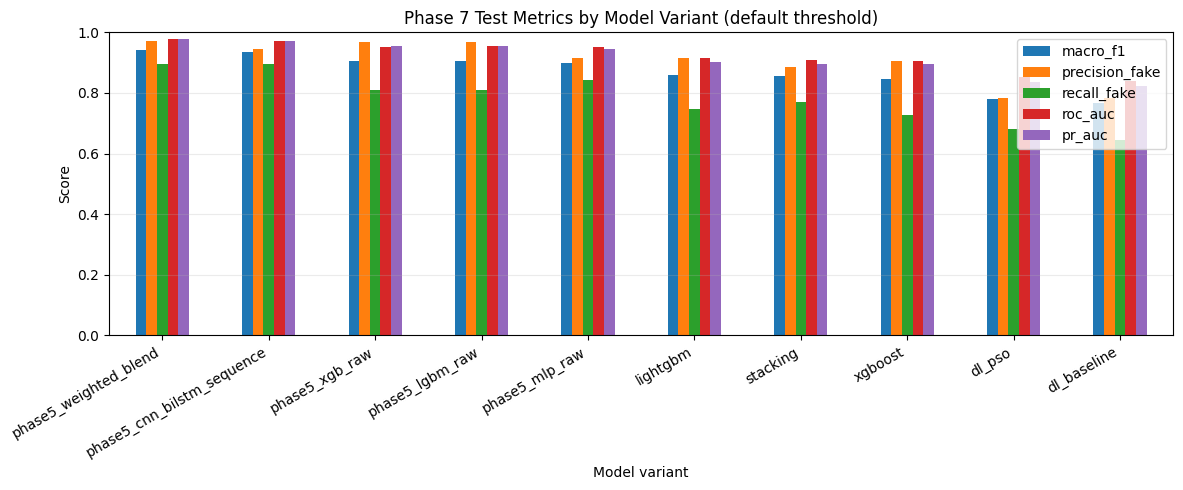

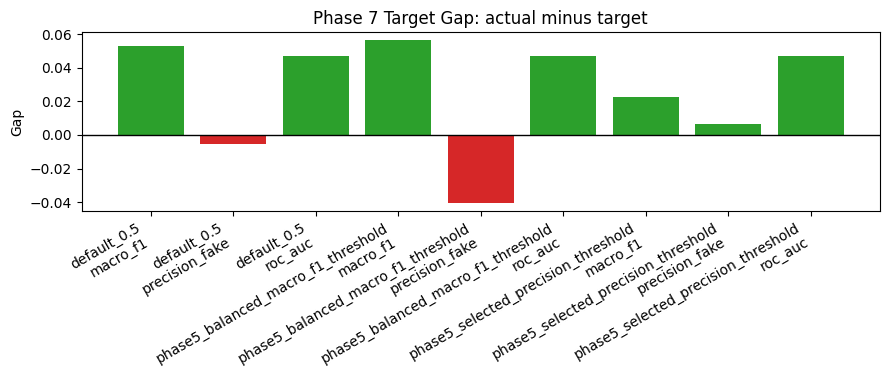

Saved figures: /content/drive/MyDrive/BaoMatCuoiKy/Fake_reviews/reports/figures/phase7_final_metrics.png /content/drive/MyDrive/BaoMatCuoiKy/Fake_reviews/reports/figures/phase7_target_gap.png


In [9]:
# test_plot_df = ...: gán giá trị cho biến test plot df
test_plot_df = final_metrics_df[
    # final_metrics_df["split"].eq("test") & final_metrics_df["threshold_strategy"].is...: ép kiểu chuỗi
    final_metrics_df["split"].eq("test") & final_metrics_df["threshold_strategy"].isin(["default_0.5", "phase5_selected_precision_threshold"])
# ].copy(): thực thi lệnh Python
].copy()
# plot_default_df = ...: ép kiểu chuỗi
plot_default_df = test_plot_df[test_plot_df["threshold_strategy"].eq("default_0.5")].copy()
# plot_default_df = ...: gán giá trị cho biến plot default df
plot_default_df = plot_default_df.sort_values("macro_f1", ascending=False)

# fig, ax = plt.subplots(figsize=(12, 5)): thực thi lệnh Python
fig, ax = plt.subplots(figsize=(12, 5))
# metrics_to_plot = ...: gán giá trị cho biến metrics to plot
metrics_to_plot = ["macro_f1", "precision_fake", "recall_fake", "roc_auc", "pr_auc"]
# plot_default_df.set_index("model_variant")[metrics_to_plot].plot(kind="bar", ax=...: tạo tập hợp
plot_default_df.set_index("model_variant")[metrics_to_plot].plot(kind="bar", ax=ax, ylim=(0, 1))
# ax.set_title("Phase 7 Test Metrics by Model Variant (default threshold)"): xóa biến để giải phóng RAM/VRAM
ax.set_title("Phase 7 Test Metrics by Model Variant (default threshold)")
# ax.set_ylabel("Score"): tạo tập hợp
ax.set_ylabel("Score")
# ax.set_xlabel("Model variant"): xóa biến để giải phóng RAM/VRAM
ax.set_xlabel("Model variant")
# ax.grid(axis="y", alpha=0.25): thực thi lệnh Python
ax.grid(axis="y", alpha=0.25)
# plt.xticks(rotation=30, ha="right"): thực thi lệnh Python
plt.xticks(rotation=30, ha="right")
# plt.tight_layout(): tự chỉnh lề biểu đồ
plt.tight_layout()
# final_metrics_figure_path = ...: gán giá trị cho biến final metrics figure path
final_metrics_figure_path = REPORT_FIGURE_DIR / "phase7_final_metrics.png"
# plt.savefig(final_metrics_figure_path, dpi=160, bbox_inches="tight"): lưu biểu đồ ra file hình
plt.savefig(final_metrics_figure_path, dpi=160, bbox_inches="tight")
# plt.show(): hiển thị biểu đồ
plt.show()

# fig, ax = plt.subplots(figsize=(9, 4)): thực thi lệnh Python
fig, ax = plt.subplots(figsize=(9, 4))
# gap_plot_df = ...: gán giá trị cho biến gap plot df
gap_plot_df = target_audit_df.copy()
# gap_plot_df["strategy_metric"] = gap_plot_df["threshold_strategy"] + "\n" + gap_...: ép kiểu chuỗi
gap_plot_df["strategy_metric"] = gap_plot_df["threshold_strategy"] + "\n" + gap_plot_df["metric"]
# colors = ...: gán giá trị cho biến colors
colors = gap_plot_df["pass"].map({True: "#2ca02c", False: "#d62728"}).tolist()
# ax.bar(gap_plot_df["strategy_metric"], gap_plot_df["gap_actual_minus_target"], c...: ép kiểu chuỗi
ax.bar(gap_plot_df["strategy_metric"], gap_plot_df["gap_actual_minus_target"], color=colors)
# ax.axhline(0.0, color="black", linewidth=1): thực thi lệnh Python
ax.axhline(0.0, color="black", linewidth=1)
# ax.set_title("Phase 7 Target Gap: actual minus target"): tạo tập hợp
ax.set_title("Phase 7 Target Gap: actual minus target")
# ax.set_ylabel("Gap"): tạo tập hợp
ax.set_ylabel("Gap")
# plt.xticks(rotation=30, ha="right"): thực thi lệnh Python
plt.xticks(rotation=30, ha="right")
# plt.tight_layout(): tự chỉnh lề biểu đồ
plt.tight_layout()
# target_gap_figure_path = ...: gán giá trị cho biến target gap figure path
target_gap_figure_path = REPORT_FIGURE_DIR / "phase7_target_gap.png"
# plt.savefig(target_gap_figure_path, dpi=160, bbox_inches="tight"): lưu biểu đồ ra file hình
plt.savefig(target_gap_figure_path, dpi=160, bbox_inches="tight")
# plt.show(): hiển thị biểu đồ
plt.show()

# print("Saved figures:", final_metrics_figure_path, target_gap_figure_path): in thông tin ra console
print("Saved figures:", final_metrics_figure_path, target_gap_figure_path)

## 3. Resource-Aware 5-Fold Cross-Validation

The default CV evidence uses LightGBM on Phase 3 PCA train+validation features. It does not rerun PSO or the full hybrid stack.

In [10]:
# stratified_sample_indices: hàm xử lý stratified sample indices
def stratified_sample_indices(labels: np.ndarray, max_rows: int | None, seed: int) -> np.ndarray:
    # labels = ...: gán giá trị cho biến labels
    labels = np.asarray(labels).reshape(-1)
    # if: điều kiện — if max_rows is None or len(labels) <= int(max_rows):
    if max_rows is None or len(labels) <= int(max_rows):
        # return: trả kết quả từ hàm
        return np.arange(len(labels), dtype=int)
    # splitter = ...: ép kiểu số nguyên
    splitter = StratifiedShuffleSplit(n_splits=1, train_size=int(max_rows), random_state=seed)
    # selected_idx, _ = next(splitter.split(np.zeros(len(labels)), labels)): đếm số phần tử
    selected_idx, _ = next(splitter.split(np.zeros(len(labels)), labels))
    # return: ép kiểu dữ liệu cột
    return np.sort(selected_idx.astype(int))


# lightgbm_config: hàm xử lý lightgbm config
def lightgbm_config(seed: int = SEED) -> dict[str, Any]:
    # return: trả kết quả từ hàm
    return {
        # "n_estimators": 350,: thực thi lệnh Python
        "n_estimators": 350,
        # "learning_rate": 0.045,: thực thi lệnh Python
        "learning_rate": 0.045,
        # "num_leaves": 63,: thực thi lệnh Python
        "num_leaves": 63,
        # "max_depth": -1,: lấy giá trị lớn nhất
        "max_depth": -1,
        # "min_child_samples": 30,: lấy giá trị nhỏ nhất
        "min_child_samples": 30,
        # "subsample": 0.85,: thực thi lệnh Python
        "subsample": 0.85,
        # "subsample_freq": 1,: thực thi lệnh Python
        "subsample_freq": 1,
        # "colsample_bytree": 0.85,: thực thi lệnh Python
        "colsample_bytree": 0.85,
        # "reg_alpha": 0.1,: thực thi lệnh Python
        "reg_alpha": 0.1,
        # "reg_lambda": 0.5,: thực thi lệnh Python
        "reg_lambda": 0.5,
        # "class_weight": "balanced",: thực thi lệnh Python
        "class_weight": "balanced",
        # "random_state": seed,: thực thi lệnh Python
        "random_state": seed,
        # "n_jobs": -1,: thực thi lệnh Python
        "n_jobs": -1,
        # "verbose": -1,: thực thi lệnh Python
        "verbose": -1,
    # }: đóng khối từ điển
    }


# fit_lightgbm_predict: hàm xử lý fit lightgbm predict
def fit_lightgbm_predict(X_train: np.ndarray, y_train: np.ndarray, X_eval: np.ndarray, *, seed: int = SEED) -> np.ndarray:
    # model = ...: xóa biến để giải phóng RAM/VRAM
    model = LGBMClassifier(**lightgbm_config(seed))
    # model.fit(X_train, y_train): fit model/reducer trên dữ liệu train
    model.fit(X_train, y_train)
    # return: dự đoán nhãn/xác suất
    return model.predict_proba(X_eval)[:, FAKE_LABEL]


# array_memory_mb: ước lượng RAM mảng (MB)
def array_memory_mb(array: np.ndarray) -> float:
    # return: trả kết quả từ hàm
    return float(np.prod(array.shape) * array.dtype.itemsize / (1024**2))


# cv_rows = ...: gán giá trị cho biến cv rows
cv_rows = []
# cv_mode = ...: gán giá trị cho biến cv mode
cv_mode = "full_5fold_cv"
# cv_reason = ...: fit model/reducer trên dữ liệu train
cv_reason = "full train+val PCA features fit within configured resource policy"
# cv_start = ...: gán giá trị cho biến cv start
cv_start = time.time()

# if: điều kiện — if CV_RUN_LIGHTGBM or CV_RUN_LOGISTIC_BASELINE:
if CV_RUN_LIGHTGBM or CV_RUN_LOGISTIC_BASELINE:
    # X_train_val = ...: gán giá trị cho biến X train val
    X_train_val = np.vstack([
        # np.asarray(np.load(PCA_FEATURE_PATHS["train"], mmap_mode="r"), dtype=np.float32)...: nạp mảng từ file .npy
        np.asarray(np.load(PCA_FEATURE_PATHS["train"], mmap_mode="r"), dtype=np.float32),
        # np.asarray(np.load(PCA_FEATURE_PATHS["val"], mmap_mode="r"), dtype=np.float32),: nạp mảng từ file .npy
        np.asarray(np.load(PCA_FEATURE_PATHS["val"], mmap_mode="r"), dtype=np.float32),
    # ]): đóng list comprehension hoặc danh sách
    ])
    # y_train_val = ...: nối các mảng numpy
    y_train_val = np.concatenate([y["train"], y["val"]])
    # selected_cv_idx = ...: ép kiểu chuỗi
    selected_cv_idx = stratified_sample_indices(y_train_val, CV_MAX_ROWS, SEED)
    # if: điều kiện — if len(selected_cv_idx) < len(y_train_val):
    if len(selected_cv_idx) < len(y_train_val):
        # cv_mode = ...: gán giá trị cho biến cv mode
        cv_mode = "reduced_resource_cv"
        # cv_reason = ...: gán giá trị cho biến cv reason
        cv_reason = f"CV_MAX_ROWS={CV_MAX_ROWS} selected by config"
        # PHASE7_FALLBACKS.append({"kind": "cv", "reason": cv_reason, "decision": "stratif...: ép kiểu chuỗi
        PHASE7_FALLBACKS.append({"kind": "cv", "reason": cv_reason, "decision": "stratified_sample_train_val"})
    # X_cv = ...: ép kiểu dữ liệu cột
    X_cv = X_train_val[selected_cv_idx].astype(np.float32, copy=False)
    # y_cv = ...: ép kiểu dữ liệu cột
    y_cv = y_train_val[selected_cv_idx].astype(int, copy=False)
    # print("CV rows:", len(y_cv), "features:", X_cv.shape[1], "memory_mb:", round(arr...: in thông tin ra console
    print("CV rows:", len(y_cv), "features:", X_cv.shape[1], "memory_mb:", round(array_memory_mb(X_cv), 2), "mode:", cv_mode)

    # cv = ...: gán giá trị cho biến cv
    cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)
    # for: vòng lặp — for fold, (train_idx, val_idx) in enumerate(cv.split(X_cv, y
    for fold, (train_idx, val_idx) in enumerate(cv.split(X_cv, y_cv), start=1):
        # X_fold_train, y_fold_train = X_cv[train_idx], y_cv[train_idx]: thực thi lệnh Python
        X_fold_train, y_fold_train = X_cv[train_idx], y_cv[train_idx]
        # X_fold_val, y_fold_val = X_cv[val_idx], y_cv[val_idx]: thực thi lệnh Python
        X_fold_val, y_fold_val = X_cv[val_idx], y_cv[val_idx]
        # if: điều kiện — if CV_RUN_LIGHTGBM:
        if CV_RUN_LIGHTGBM:
            # fold_prob = ...: dự đoán nhãn/xác suất
            fold_prob = fit_lightgbm_predict(X_fold_train, y_fold_train, X_fold_val, seed=SEED + fold)
            # row = ...: gán giá trị cho biến row
            row = evaluate_probabilities(
                # y_fold_val,: thực thi lệnh Python
                y_fold_val,
                # fold_prob,: thực thi lệnh Python
                fold_prob,
                # split = ...: gán giá trị cho biến split
                split=f"cv_fold_{fold}",
                # model_variant = ...: gán giá trị cho biến model variant
                model_variant="cv_lightgbm_pca",
                # threshold = ...: gán giá trị cho biến threshold
                threshold=DEFAULT_THRESHOLD,
                # threshold_strategy = ...: ép kiểu chuỗi
                threshold_strategy="default_0.5",
                # evidence_type = ...: gán giá trị cho biến evidence type
                evidence_type="resource_aware_cv",
                # notes = ...: gán giá trị cho biến notes
                notes=cv_reason,
            # ): đóng ngoặc gọi hàm
            )
            # row.update({"fold": fold, "train_rows": len(train_idx), "validation_rows": len(v...: đếm số phần tử
            row.update({"fold": fold, "train_rows": len(train_idx), "validation_rows": len(val_idx), "cv_mode": cv_mode})
            # cv_rows.append(row): thực thi lệnh Python
            cv_rows.append(row)
        # if: điều kiện — if CV_RUN_LOGISTIC_BASELINE:
        if CV_RUN_LOGISTIC_BASELINE:
            # log_model = ...: xóa biến để giải phóng RAM/VRAM
            log_model = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED + fold, n_jobs=-1)
            # log_model.fit(X_fold_train, y_fold_train): fit model/reducer trên dữ liệu train
            log_model.fit(X_fold_train, y_fold_train)
            # fold_prob = ...: dự đoán nhãn/xác suất
            fold_prob = log_model.predict_proba(X_fold_val)[:, FAKE_LABEL]
            # row = ...: gán giá trị cho biến row
            row = evaluate_probabilities(
                # y_fold_val,: thực thi lệnh Python
                y_fold_val,
                # fold_prob,: thực thi lệnh Python
                fold_prob,
                # split = ...: gán giá trị cho biến split
                split=f"cv_fold_{fold}",
                # model_variant = ...: gán giá trị cho biến model variant
                model_variant="cv_logistic_pca",
                # threshold = ...: gán giá trị cho biến threshold
                threshold=DEFAULT_THRESHOLD,
                # threshold_strategy = ...: ép kiểu chuỗi
                threshold_strategy="default_0.5",
                # evidence_type = ...: gán giá trị cho biến evidence type
                evidence_type="resource_aware_cv",
                # notes = ...: gán giá trị cho biến notes
                notes=cv_reason,
            # ): đóng ngoặc gọi hàm
            )
            # row.update({"fold": fold, "train_rows": len(train_idx), "validation_rows": len(v...: đếm số phần tử
            row.update({"fold": fold, "train_rows": len(train_idx), "validation_rows": len(val_idx), "cv_mode": cv_mode})
            # cv_rows.append(row): thực thi lệnh Python
            cv_rows.append(row)
        # gc.collect(): giải phóng bộ nhớ
        gc.collect()
# else: nhánh còn lại của điều kiện
else:
    # cv_mode = ...: gán giá trị cho biến cv mode
    cv_mode = "skipped_by_config"
    # cv_reason = ...: gán giá trị cho biến cv reason
    cv_reason = "CV_RUN_LIGHTGBM and CV_RUN_LOGISTIC_BASELINE are both False"
    # PHASE7_FALLBACKS.append({"kind": "cv", "reason": cv_reason, "decision": "skip_cv...: thực thi lệnh Python
    PHASE7_FALLBACKS.append({"kind": "cv", "reason": cv_reason, "decision": "skip_cv"})

# cv_metrics_df = ...: gán giá trị cho biến cv metrics df
cv_metrics_df = pd.DataFrame(cv_rows)
# cv_metrics_path = ...: gán giá trị cho biến cv metrics path
cv_metrics_path = REPORT_TABLE_DIR / "phase7_cv_metrics.csv"
# cv_metrics_df.to_csv(cv_metrics_path, index=False): ghi DataFrame ra file CSV
cv_metrics_df.to_csv(cv_metrics_path, index=False)
# if: điều kiện — if not cv_metrics_df.empty:
if not cv_metrics_df.empty:
    # cv_summary_df = ...: tính tổng
    cv_summary_df = (
        # cv_metrics_df.groupby(["model_variant", "cv_mode"], as_index=False): nhóm dữ liệu theo cột
        cv_metrics_df.groupby(["model_variant", "cv_mode"], as_index=False)
        # .agg(: thực thi lệnh Python
        .agg(
            # folds = ...: gán giá trị cho biến folds
            folds=("fold", "nunique"),
            # sample_rows = ...: tính tổng
            sample_rows=("validation_rows", "sum"),
            # macro_f1_mean = ...: tính trung bình
            macro_f1_mean=("macro_f1", "mean"),
            # macro_f1_std = ...: gán giá trị cho biến macro f1 std
            macro_f1_std=("macro_f1", "std"),
            # precision_fake_mean = ...: tính trung bình
            precision_fake_mean=("precision_fake", "mean"),
            # precision_fake_std = ...: gán giá trị cho biến precision fake std
            precision_fake_std=("precision_fake", "std"),
            # recall_fake_mean = ...: tính trung bình
            recall_fake_mean=("recall_fake", "mean"),
            # roc_auc_mean = ...: tính trung bình
            roc_auc_mean=("roc_auc", "mean"),
            # roc_auc_std = ...: gán giá trị cho biến roc auc std
            roc_auc_std=("roc_auc", "std"),
            # pr_auc_mean = ...: tính trung bình
            pr_auc_mean=("pr_auc", "mean"),
        # ): đóng ngoặc gọi hàm
        )
    # ): đóng ngoặc gọi hàm
    )
# else: nhánh còn lại của điều kiện
else:
    # cv_summary_df = ...: tính tổng
    cv_summary_df = pd.DataFrame([
        # {: thực thi lệnh Python
        {
            # "model_variant": "none",: thực thi lệnh Python
            "model_variant": "none",
            # "cv_mode": cv_mode,: thực thi lệnh Python
            "cv_mode": cv_mode,
            # "folds": 0,: thực thi lệnh Python
            "folds": 0,
            # "sample_rows": 0,: thực thi lệnh Python
            "sample_rows": 0,
            # "macro_f1_mean": np.nan,: tính trung bình
            "macro_f1_mean": np.nan,
            # "precision_fake_mean": np.nan,: tính trung bình
            "precision_fake_mean": np.nan,
            # "roc_auc_mean": np.nan,: tính trung bình
            "roc_auc_mean": np.nan,
            # "reason": cv_reason,: thực thi lệnh Python
            "reason": cv_reason,
        # }: đóng khối từ điển
        }
    # ]): đóng list comprehension hoặc danh sách
    ])
# cv_summary_df["generated_at_utc"] = utc_now(): tính tổng
cv_summary_df["generated_at_utc"] = utc_now()
# cv_summary_df["seed"] = SEED: tính tổng
cv_summary_df["seed"] = SEED
# cv_summary_df["duration_seconds"] = round(time.time() - cv_start, 2): làm tròn số
cv_summary_df["duration_seconds"] = round(time.time() - cv_start, 2)
# cv_summary_path = ...: tính tổng
cv_summary_path = REPORT_TABLE_DIR / "phase7_cv_summary.csv"
# cv_summary_df.to_csv(cv_summary_path, index=False): ghi DataFrame ra file CSV
cv_summary_df.to_csv(cv_summary_path, index=False)
# display(cv_metrics_df.head()): hiển thị bảng/kết quả trên notebook
display(cv_metrics_df.head())
# display(cv_summary_df): hiển thị bảng/kết quả trên notebook
display(cv_summary_df)
# print("Saved CV outputs:", cv_metrics_path, cv_summary_path): in thông tin ra console
print("Saved CV outputs:", cv_metrics_path, cv_summary_path)


CV rows: 36336 features: 400 memory_mb: 55.44 mode: full_5fold_cv


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,generated_at_utc,seed,split,model_variant,ablation_variant,removed_component,evidence_type,threshold,threshold_strategy,accuracy,...,tn,fp,fn,tp,probability_path,notes,fold,train_rows,validation_rows,cv_mode
0,2026-06-11T12:19:22.625373+00:00,42,cv_fold_1,cv_lightgbm_pca,None,None,resource_aware_cv,0.5,default_0.5,0.871904,...,4039,255,676,2298,None,full train+val PCA features fit within configu...,1,29068,7268,full_5fold_cv
1,2026-06-11T12:21:00.140165+00:00,42,cv_fold_2,cv_lightgbm_pca,None,None,resource_aware_cv,0.5,default_0.5,0.873263,...,4030,263,658,2316,None,full train+val PCA features fit within configu...,2,29069,7267,full_5fold_cv
2,2026-06-11T12:22:35.876219+00:00,42,cv_fold_3,cv_lightgbm_pca,None,None,resource_aware_cv,0.5,default_0.5,0.869134,...,4033,260,691,2283,None,full train+val PCA features fit within configu...,3,29069,7267,full_5fold_cv
3,2026-06-11T12:24:14.494222+00:00,42,cv_fold_4,cv_lightgbm_pca,None,None,resource_aware_cv,0.5,default_0.5,0.876703,...,4068,225,671,2303,None,full train+val PCA features fit within configu...,4,29069,7267,full_5fold_cv
4,2026-06-11T12:25:49.198269+00:00,42,cv_fold_5,cv_lightgbm_pca,None,None,resource_aware_cv,0.5,default_0.5,0.877253,...,4060,233,659,2315,None,full train+val PCA features fit within configu...,5,29069,7267,full_5fold_cv


,model_variant,cv_mode,folds,sample_rows,macro_f1_mean,macro_f1_std,precision_fake_mean,precision_fake_std,recall_fake_mean,roc_auc_mean,roc_auc_std,pr_auc_mean,generated_at_utc,seed,duration_seconds
0,cv_lightgbm_pca,full_5fold_cv,5,36336,0.86594,0.00356,0.90309,0.006232,0.774378,0.923336,0.004081,0.914759,2026-06-11T12:25:49.694725+00:00,42,483.58


Saved CV outputs: /content/drive/MyDrive/BaoMatCuoiKy/Fake_reviews/reports/tables/phase7_cv_metrics.csv /content/drive/MyDrive/BaoMatCuoiKy/Fake_reviews/reports/tables/phase7_cv_summary.csv


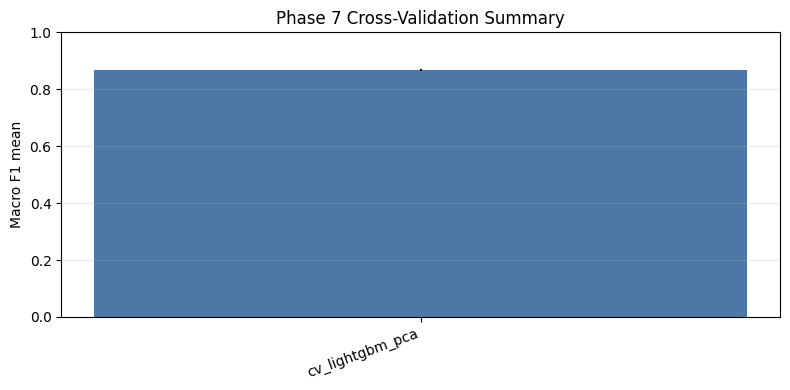

Saved CV figure: /content/drive/MyDrive/BaoMatCuoiKy/Fake_reviews/reports/figures/phase7_cv_summary.png


In [11]:
# if: điều kiện — if not cv_summary_df.empty and "macro_f1_mean" in cv_summary
if not cv_summary_df.empty and "macro_f1_mean" in cv_summary_df.columns:
    # plot_cv_df = ...: tính tổng
    plot_cv_df = cv_summary_df[cv_summary_df["model_variant"].ne("none")].copy()
    # if: điều kiện — if not plot_cv_df.empty:
    if not plot_cv_df.empty:
        # fig, ax = plt.subplots(figsize=(8, 4)): thực thi lệnh Python
        fig, ax = plt.subplots(figsize=(8, 4))
        # ax.bar(plot_cv_df["model_variant"], plot_cv_df["macro_f1_mean"], yerr=plot_cv_df...: tính trung bình
        ax.bar(plot_cv_df["model_variant"], plot_cv_df["macro_f1_mean"], yerr=plot_cv_df.get("macro_f1_std"), color="#4C78A8")
        # ax.set_ylim(0, 1): tạo tập hợp
        ax.set_ylim(0, 1)
        # ax.set_ylabel("Macro F1 mean"): tính trung bình
        ax.set_ylabel("Macro F1 mean")
        # ax.set_title("Phase 7 Cross-Validation Summary"): tạo tập hợp
        ax.set_title("Phase 7 Cross-Validation Summary")
        # ax.grid(axis="y", alpha=0.25): thực thi lệnh Python
        ax.grid(axis="y", alpha=0.25)
        # plt.xticks(rotation=20, ha="right"): thực thi lệnh Python
        plt.xticks(rotation=20, ha="right")
        # plt.tight_layout(): tự chỉnh lề biểu đồ
        plt.tight_layout()
        # cv_summary_figure_path = ...: tính tổng
        cv_summary_figure_path = REPORT_FIGURE_DIR / "phase7_cv_summary.png"
        # plt.savefig(cv_summary_figure_path, dpi=160, bbox_inches="tight"): lưu biểu đồ ra file hình
        plt.savefig(cv_summary_figure_path, dpi=160, bbox_inches="tight")
        # plt.show(): hiển thị biểu đồ
        plt.show()
    # else: nhánh còn lại của điều kiện
    else:
        # cv_summary_figure_path = ...: tính tổng
        cv_summary_figure_path = None
# else: nhánh còn lại của điều kiện
else:
    # cv_summary_figure_path = ...: tính tổng
    cv_summary_figure_path = None
# print("Saved CV figure:", cv_summary_figure_path): in thông tin ra console
print("Saved CV figure:", cv_summary_figure_path)


## 4. Ablation Study A-E

The ablation table separates direct artifacts from controlled surrogate experiments. This is important because Phase 7 should prove component value without pretending every ablation is a full retrain of the whole hybrid pipeline.

In [12]:
# evaluate_test_probability: hàm xử lý evaluate test probability
def evaluate_test_probability(model_variant: str, threshold: float = DEFAULT_THRESHOLD, threshold_strategy: str = "default_0.5", **kwargs) -> dict[str, Any]:
    # return: trả kết quả từ hàm
    return evaluate_probabilities(
        # y["test"],: thực thi lệnh Python
        y["test"],
        # probabilities[model_variant]["test"],: thực thi lệnh Python
        probabilities[model_variant]["test"],
        # split = ...: gán giá trị cho biến split
        split="test",
        # model_variant = ...: gán giá trị cho biến model variant
        model_variant=model_variant,
        # threshold = ...: gán giá trị cho biến threshold
        threshold=threshold,
        # threshold_strategy = ...: ép kiểu chuỗi
        threshold_strategy=threshold_strategy,
        # probability_path = ...: ép kiểu chuỗi
        probability_path=str(PROBABILITY_PATHS[model_variant]["test"]),
        # **kwargs,: thực thi lệnh Python
        **kwargs,
    # ): đóng ngoặc gọi hàm
    )


# selected_weighted_blend: hàm xử lý selected weighted blend
def selected_weighted_blend(split: str, *, replace_dl_with_baseline: bool = False) -> tuple[np.ndarray | None, str]:
    # config = ...: gán giá trị cho biến config
    config = selected_candidate_config or {}
    # if: điều kiện — if config.get("type") != "weighted_blend":
    if config.get("type") != "weighted_blend":
        # return: trả kết quả từ hàm
        return None, "Selected candidate is not a weighted_blend; cannot reconstruct no-PSO blend directly."
    # weights = ...: gán giá trị cho biến weights
    weights = config.get("weights", {}) or {}
    # dl_key = ...: gán giá trị cho biến dl key
    dl_key = "dl_baseline" if replace_dl_with_baseline else "dl_pso"
    # parts = ...: gán giá trị cho biến parts
    parts = []
    # total_weight = ...: gán giá trị cho biến total weight
    total_weight = 0.0
    # key_to_model = ...: xóa biến để giải phóng RAM/VRAM
    key_to_model = {
        # "dl_pso_prob": dl_key,: thực thi lệnh Python
        "dl_pso_prob": dl_key,
        # "xgboost_prob": "xgboost",: thực thi lệnh Python
        "xgboost_prob": "xgboost",
        # "lightgbm_prob": "lightgbm",: thực thi lệnh Python
        "lightgbm_prob": "lightgbm",
        # "stacking_prob": "stacking",: thực thi lệnh Python
        "stacking_prob": "stacking",
    # }: đóng khối từ điển
    }
    # for: vòng lặp — for weight_key, model_name in key_to_model.items():
    for weight_key, model_name in key_to_model.items():
        # weight = ...: ép kiểu số thực
        weight = float(weights.get(weight_key, 0.0) or 0.0)
        # if: điều kiện — if weight != 0.0:
        if weight != 0.0:
            # parts.append(weight * probabilities[model_name][split]): thực thi lệnh Python
            parts.append(weight * probabilities[model_name][split])
            # total_weight += weight: thực thi lệnh Python
            total_weight += weight
    # if: điều kiện — if not parts or total_weight == 0.0:
    if not parts or total_weight == 0.0:
        # return: trả kết quả từ hàm
        return None, "Selected weighted blend has no non-zero reconstructable weights."
    # return: trả kết quả từ hàm
    return np.sum(parts, axis=0) / total_weight, "reconstructed_selected_weighted_blend"


# controlled_train_eval: hàm xử lý controlled train eval
def controlled_train_eval(
    # X_train: np.ndarray,: thực thi lệnh Python
    X_train: np.ndarray,
    # y_train: np.ndarray,: thực thi lệnh Python
    y_train: np.ndarray,
    # X_test: np.ndarray,: thực thi lệnh Python
    X_test: np.ndarray,
    # y_test: np.ndarray,: thực thi lệnh Python
    y_test: np.ndarray,
    # *,: thực thi lệnh Python
    *,
    # model_variant: str,: ép kiểu chuỗi
    model_variant: str,
    # evidence_type: str,: ép kiểu chuỗi
    evidence_type: str,
    # notes: str,: ép kiểu chuỗi
    notes: str,
    # seed_offset: int = 0,: tạo tập hợp
    seed_offset: int = 0,
# ) -> tuple[dict[str, Any], np.ndarray]:: tạo dictionary
) -> tuple[dict[str, Any], np.ndarray]:
    # train_idx = ...: tạo tập hợp
    train_idx = stratified_sample_indices(y_train, CONTROLLED_ABLATION_MAX_ROWS, SEED + seed_offset)
    # sample_mode = ...: đếm số phần tử
    sample_mode = "full_train" if len(train_idx) == len(y_train) else f"stratified_sample_{len(train_idx)}"
    # if: điều kiện — if sample_mode != "full_train":
    if sample_mode != "full_train":
        # PHASE7_FALLBACKS.append({"kind": "controlled_ablation", "reason": f"CONTROLLED_A...: thực thi lệnh Python
        PHASE7_FALLBACKS.append({"kind": "controlled_ablation", "reason": f"CONTROLLED_ABLATION_MAX_ROWS={CONTROLLED_ABLATION_MAX_ROWS}", "decision": sample_mode, "model_variant": model_variant})
    # X_fit = ...: ép kiểu số thực
    X_fit = np.asarray(X_train[train_idx], dtype=np.float32)
    # y_fit = ...: fit model/reducer trên dữ liệu train
    y_fit = np.asarray(y_train[train_idx], dtype=int)
    # model = ...: xóa biến để giải phóng RAM/VRAM
    model = LGBMClassifier(**lightgbm_config(SEED + seed_offset))
    # start = ...: gán giá trị cho biến start
    start = time.time()
    # model.fit(X_fit, y_fit): fit model/reducer trên dữ liệu train
    model.fit(X_fit, y_fit)
    # prob = ...: dự đoán nhãn/xác suất
    prob = model.predict_proba(np.asarray(X_test, dtype=np.float32))[:, FAKE_LABEL]
    # row = ...: gán giá trị cho biến row
    row = evaluate_probabilities(
        # y_test,: thực thi lệnh Python
        y_test,
        # prob,: thực thi lệnh Python
        prob,
        # split = ...: gán giá trị cho biến split
        split="test",
        # model_variant = ...: gán giá trị cho biến model variant
        model_variant=model_variant,
        # threshold = ...: gán giá trị cho biến threshold
        threshold=DEFAULT_THRESHOLD,
        # threshold_strategy = ...: ép kiểu chuỗi
        threshold_strategy="default_0.5",
        # evidence_type = ...: gán giá trị cho biến evidence type
        evidence_type=evidence_type,
        # notes = ...: gán giá trị cho biến notes
        notes=f"{notes}; train_mode={sample_mode}; train_seconds={time.time() - start:.2f}",
    # ): đóng ngoặc gọi hàm
    )
    # row.update({: thực thi lệnh Python
    row.update({
        # "controlled_train_rows": int(len(train_idx)),: đếm số phần tử
        "controlled_train_rows": int(len(train_idx)),
        # "controlled_feature_dim": int(np.asarray(X_test).shape[1]),: ép kiểu số nguyên
        "controlled_feature_dim": int(np.asarray(X_test).shape[1]),
        # "controlled_train_mode": sample_mode,: thực thi lệnh Python
        "controlled_train_mode": sample_mode,
    # }): đóng từ điển hoặc DataFrame constructor
    })
    # del X_fit, y_fit, model: xóa biến để giải phóng RAM/VRAM
    del X_fit, y_fit, model
    # gc.collect(): giải phóng bộ nhớ
    gc.collect()
    # return: trả kết quả từ hàm
    return row, prob


# build_basic_behavioral_features: hàm xử lý build basic behavioral features
def build_basic_behavioral_features() -> tuple[np.ndarray, np.ndarray, np.ndarray, dict[str, Any]]:
    # bert_dim = ...: ép kiểu số nguyên
    bert_dim = int(phase2_metadata.get("bert", {}).get("embedding_dim", 768))
    # behavioral_meta = ...: gán giá trị cho biến behavioral meta
    behavioral_meta = phase2_metadata.get("behavioral_features", {})
    # all_behavioral = ...: gán giá trị cho biến all behavioral
    all_behavioral = behavioral_meta.get("all", [])
    # basic_behavioral = ...: gán giá trị cho biến basic behavioral
    basic_behavioral = behavioral_meta.get("basic", [])
    # if: điều kiện — if not all_behavioral or not basic_behavioral:
    if not all_behavioral or not basic_behavioral:
        # basic_indices = ...: tạo dãy số cho vòng lặp
        basic_indices = list(range(5))
        # feature_note = ...: gán giá trị cho biến feature note
        feature_note = "behavioral metadata missing; fallback kept first five behavioral columns"
    # else: nhánh còn lại của điều kiện
    else:
        # name_to_idx = ...: lặp kèm chỉ số
        name_to_idx = {name: idx for idx, name in enumerate(all_behavioral)}
        # basic_indices = ...: gán giá trị cho biến basic indices
        basic_indices = [name_to_idx[name] for name in basic_behavioral if name in name_to_idx]
        # feature_note = ...: gán giá trị cho biến feature note
        feature_note = "basic behavioral columns selected from Phase 2 metadata"
    # keep_indices = ...: tạo dãy số cho vòng lặp
    keep_indices = list(range(bert_dim)) + [bert_dim + idx for idx in basic_indices]
    # raw_train = ...: nạp mảng từ file .npy
    raw_train = np.load(RAW_FEATURE_PATHS["train"], mmap_mode="r")
    # raw_val = ...: nạp mảng từ file .npy
    raw_val = np.load(RAW_FEATURE_PATHS["val"], mmap_mode="r")
    # raw_test = ...: nạp mảng từ file .npy
    raw_test = np.load(RAW_FEATURE_PATHS["test"], mmap_mode="r")
    # X_train_basic = ...: ép kiểu số thực
    X_train_basic = np.asarray(raw_train[:, keep_indices], dtype=np.float32)
    # X_val_basic = ...: ép kiểu số thực
    X_val_basic = np.asarray(raw_val[:, keep_indices], dtype=np.float32)
    # X_test_basic = ...: ép kiểu số thực
    X_test_basic = np.asarray(raw_test[:, keep_indices], dtype=np.float32)
    # info = ...: gán giá trị cho biến info
    info = {
        # "bert_dim": bert_dim,: thực thi lệnh Python
        "bert_dim": bert_dim,
        # "basic_behavioral_features": basic_behavioral,: thực thi lệnh Python
        "basic_behavioral_features": basic_behavioral,
        # "kept_behavioral_indices": basic_indices,: thực thi lệnh Python
        "kept_behavioral_indices": basic_indices,
        # "selected_feature_dim": len(keep_indices),: đếm số phần tử
        "selected_feature_dim": len(keep_indices),
        # "note": feature_note,: thực thi lệnh Python
        "note": feature_note,
    # }: đóng khối từ điển
    }
    # return: trả kết quả từ hàm
    return X_train_basic, X_val_basic, X_test_basic, info


# train_only_reduce_features: hàm xử lý train only reduce features
def train_only_reduce_features(
    # X_train: np.ndarray,: thực thi lệnh Python
    X_train: np.ndarray,
    # X_val: np.ndarray,: thực thi lệnh Python
    X_val: np.ndarray,
    # X_test: np.ndarray,: thực thi lệnh Python
    X_test: np.ndarray,
    # *,: thực thi lệnh Python
    *,
    # n_components: int,: ép kiểu số nguyên
    n_components: int,
    # seed: int,: ép kiểu số nguyên
    seed: int,
# ) -> tuple[np.ndarray, np.ndarray, np.ndarray, dict[str, Any]]:: tạo dictionary
) -> tuple[np.ndarray, np.ndarray, np.ndarray, dict[str, Any]]:
    # scaler = ...: gán giá trị cho biến scaler
    scaler = StandardScaler()
    # X_train_scaled = ...: fit scaler trên train và transform
    X_train_scaled = scaler.fit_transform(X_train).astype(np.float32)
    # X_val_scaled = ...: transform dữ liệu bằng object đã fit
    X_val_scaled = scaler.transform(X_val).astype(np.float32)
    # X_test_scaled = ...: transform dữ liệu bằng object đã fit
    X_test_scaled = scaler.transform(X_test).astype(np.float32)
    # max_components = ...: lấy giá trị nhỏ nhất
    max_components = min(n_components, X_train_scaled.shape[0] - 1, X_train_scaled.shape[1])
    # if: điều kiện — if X_train_scaled.shape[1] <= max_components:
    if X_train_scaled.shape[1] <= max_components:
        # return: trả kết quả từ hàm
        return X_train_scaled, X_val_scaled, X_test_scaled, {
            # "reducer": "none",: thực thi lệnh Python
            "reducer": "none",
            # "reason": "feature_dim_not_above_component_target",: thực thi lệnh Python
            "reason": "feature_dim_not_above_component_target",
            # "output_dim": int(X_train_scaled.shape[1]),: ép kiểu số nguyên
            "output_dim": int(X_train_scaled.shape[1]),
        # }: đóng khối từ điển
        }
    # reducer = ...: lấy giá trị lớn nhất
    reducer = PCA(n_components=max_components, svd_solver="randomized", random_state=seed)
    # try/except: khối xử lý ngoại lệ
    try:
        # X_train_reduced = ...: fit scaler trên train và transform
        X_train_reduced = reducer.fit_transform(X_train_scaled).astype(np.float32)
        # X_val_reduced = ...: transform dữ liệu bằng object đã fit
        X_val_reduced = reducer.transform(X_val_scaled).astype(np.float32)
        # X_test_reduced = ...: transform dữ liệu bằng object đã fit
        X_test_reduced = reducer.transform(X_test_scaled).astype(np.float32)
        # reducer_info = ...: gán giá trị cho biến reducer info
        reducer_info = {
            # "reducer": "PCA_randomized",: thực thi lệnh Python
            "reducer": "PCA_randomized",
            # "fit_policy": "fit train only; transform val/test",: transform dữ liệu bằng object đã fit
            "fit_policy": "fit train only; transform val/test",
            # "output_dim": int(X_train_reduced.shape[1]),: ép kiểu số nguyên
            "output_dim": int(X_train_reduced.shape[1]),
            # "explained_variance_retained": float(np.sum(getattr(reducer, "explained_variance...: ép kiểu số thực
            "explained_variance_retained": float(np.sum(getattr(reducer, "explained_variance_ratio_", [np.nan]))),
        # }: đóng khối từ điển
        }
    # except: xử lý ngoại lệ — except Exception as exc:
    except Exception as exc:
        # PHASE7_FALLBACKS.append({"kind": "no_advanced_reducer", "reason": repr(exc), "de...: thực thi lệnh Python
        PHASE7_FALLBACKS.append({"kind": "no_advanced_reducer", "reason": repr(exc), "decision": "fallback_to_truncated_svd"})
        # reducer = ...: lấy giá trị lớn nhất
        reducer = TruncatedSVD(n_components=max_components, random_state=seed)
        # X_train_reduced = ...: fit scaler trên train và transform
        X_train_reduced = reducer.fit_transform(X_train_scaled).astype(np.float32)
        # X_val_reduced = ...: transform dữ liệu bằng object đã fit
        X_val_reduced = reducer.transform(X_val_scaled).astype(np.float32)
        # X_test_reduced = ...: transform dữ liệu bằng object đã fit
        X_test_reduced = reducer.transform(X_test_scaled).astype(np.float32)
        # reducer_info = ...: gán giá trị cho biến reducer info
        reducer_info = {
            # "reducer": "TruncatedSVD",: thực thi lệnh Python
            "reducer": "TruncatedSVD",
            # "fit_policy": "fit train only; transform val/test",: transform dữ liệu bằng object đã fit
            "fit_policy": "fit train only; transform val/test",
            # "output_dim": int(X_train_reduced.shape[1]),: ép kiểu số nguyên
            "output_dim": int(X_train_reduced.shape[1]),
            # "explained_variance_retained": float(np.sum(getattr(reducer, "explained_variance...: ép kiểu số thực
            "explained_variance_retained": float(np.sum(getattr(reducer, "explained_variance_ratio_", [np.nan]))),
        # }: đóng khối từ điển
        }
    # del X_train_scaled, X_val_scaled, X_test_scaled, scaler, reducer: xóa biến để giải phóng RAM/VRAM
    del X_train_scaled, X_val_scaled, X_test_scaled, scaler, reducer
    # gc.collect(): giải phóng bộ nhớ
    gc.collect()
    # return: trả kết quả từ hàm
    return X_train_reduced, X_val_reduced, X_test_reduced, reducer_info


In [13]:
# ablation_rows = ...: gán giá trị cho biến ablation rows
ablation_rows = []
# controlled_reference_rows = ...: gán giá trị cho biến controlled reference rows
controlled_reference_rows = []
# controlled_probabilities: dict[str, np.ndarray] = {}: tạo dictionary
controlled_probabilities: dict[str, np.ndarray] = {}

# full_row = ...: gán giá trị cho biến full row
full_row = evaluate_test_probability(
    # "phase5_weighted_blend",: đếm số phần tử
    "phase5_weighted_blend",
    # ablation_variant = ...: gán giá trị cho biến ablation variant
    ablation_variant="Full Model",
    # removed_component = ...: gán giá trị cho biến removed component
    removed_component="none",
    # evidence_type = ...: gán giá trị cho biến evidence type
    evidence_type="direct_artifact",
    # notes = ...: đếm số phần tử
    notes="Headline phase5_weighted_blend; dual-threshold audit is exported separately.",
# ): đóng ngoặc gọi hàm
)
# ablation_rows.append(full_row): thực thi lệnh Python
ablation_rows.append(full_row)

# if: điều kiện — if PROBABILITY_PATHS['phase5_xgb_raw']['test'].exists():
if PROBABILITY_PATHS['phase5_xgb_raw']['test'].exists():
    # model_a_row = ...: gán giá trị cho biến model a row
    model_a_row = evaluate_test_probability(
        # "phase5_xgb_raw",: thực thi lệnh Python
        "phase5_xgb_raw",
        # ablation_variant = ...: xóa biến để giải phóng RAM/VRAM
        ablation_variant="Model A",
        # removed_component = ...: gán giá trị cho biến removed component
        removed_component="cnn_sequence_branch",
        # evidence_type = ...: gán giá trị cho biến evidence type
        evidence_type="direct_artifact_branch_level",
        # notes = ...: đếm số phần tử
        notes="XGB raw tabular branch only; contrasts with full CNN+XGB weighted blend.",
    # ): đóng ngoặc gọi hàm
    )
# else: nhánh còn lại của điều kiện
else:
    # model_a_row = ...: gán giá trị cho biến model a row
    model_a_row = evaluate_test_probability(
        # "dl_baseline",: thực thi lệnh Python
        "dl_baseline",
        # ablation_variant = ...: xóa biến để giải phóng RAM/VRAM
        ablation_variant="Model A",
        # removed_component = ...: gán giá trị cho biến removed component
        removed_component="legacy_pso_branch",
        # evidence_type = ...: gán giá trị cho biến evidence type
        evidence_type="direct_artifact_branch_level",
        # notes = ...: gán giá trị cho biến notes
        notes="phase5_xgb_raw probabilities missing; fallback legacy DL baseline row.",
    # ): đóng ngoặc gọi hàm
    )
# ablation_rows.append(model_a_row): thực thi lệnh Python
ablation_rows.append(model_a_row)

# if: điều kiện — if RUN_CONTROLLED_ABLATIONS:
if RUN_CONTROLLED_ABLATIONS:
    # X_pca_train = ...: nạp mảng từ file .npy
    X_pca_train = np.asarray(np.load(PCA_FEATURE_PATHS["train"], mmap_mode="r"), dtype=np.float32)
    # X_pca_test = ...: nạp mảng từ file .npy
    X_pca_test = np.asarray(np.load(PCA_FEATURE_PATHS["test"], mmap_mode="r"), dtype=np.float32)
    # controlled_pca_row, controlled_pca_prob = controlled_train_eval(: thực thi lệnh Python
    controlled_pca_row, controlled_pca_prob = controlled_train_eval(
        # X_pca_train,: thực thi lệnh Python
        X_pca_train,
        # y["train"],: thực thi lệnh Python
        y["train"],
        # X_pca_test,: thực thi lệnh Python
        X_pca_test,
        # y["test"],: thực thi lệnh Python
        y["test"],
        # model_variant = ...: gán giá trị cho biến model variant
        model_variant="controlled_lightgbm_pca_all9",
        # evidence_type = ...: gán giá trị cho biến evidence type
        evidence_type="controlled_lightgbm_reference",
        # notes = ...: ép kiểu chuỗi
        notes="Reference LightGBM trained on Phase 3 PCA features with all 9 behavioral features embedded upstream.",
        # seed_offset = ...: tạo tập hợp
        seed_offset=101,
    # ): đóng ngoặc gọi hàm
    )
    # controlled_reference_rows.append(controlled_pca_row): thực thi lệnh Python
    controlled_reference_rows.append(controlled_pca_row)
    # controlled_probabilities["controlled_lightgbm_pca_all9"] = controlled_pca_prob: thực thi lệnh Python
    controlled_probabilities["controlled_lightgbm_pca_all9"] = controlled_pca_prob

    # X_raw_train = ...: nạp mảng từ file .npy
    X_raw_train = np.load(RAW_FEATURE_PATHS["train"], mmap_mode="r")
    # X_raw_test = ...: nạp mảng từ file .npy
    X_raw_test = np.load(RAW_FEATURE_PATHS["test"], mmap_mode="r")
    # raw_memory_mb = ...: gán giá trị cho biến raw memory mb
    raw_memory_mb = array_memory_mb(X_raw_train) + array_memory_mb(X_raw_test)
    # raw_note = ...: gán giá trị cho biến raw note
    raw_note = f"Raw fused feature LightGBM without PCA; estimated loaded train+test memory {raw_memory_mb:.1f} MB."
    # if: điều kiện — if raw_memory_mb > CONTROLLED_MEMORY_LIMIT_MB and CONTROLLED
    if raw_memory_mb > CONTROLLED_MEMORY_LIMIT_MB and CONTROLLED_ABLATION_MAX_ROWS is None:
        # PHASE7_FALLBACKS.append({"kind": "model_b_no_pca", "reason": f"estimated_memory_...: tạo tập hợp
        PHASE7_FALLBACKS.append({"kind": "model_b_no_pca", "reason": f"estimated_memory_mb={raw_memory_mb:.1f} exceeds limit {CONTROLLED_MEMORY_LIMIT_MB}", "decision": "set controlled max rows automatically"})
        # CONTROLLED_ABLATION_MAX_ROWS: biến cấu hình/hằng số của notebook
        CONTROLLED_ABLATION_MAX_ROWS = 20000
    # model_b_row, model_b_prob = controlled_train_eval(: thực thi lệnh Python
    model_b_row, model_b_prob = controlled_train_eval(
        # X_raw_train,: thực thi lệnh Python
        X_raw_train,
        # y["train"],: thực thi lệnh Python
        y["train"],
        # X_raw_test,: thực thi lệnh Python
        X_raw_test,
        # y["test"],: thực thi lệnh Python
        y["test"],
        # model_variant = ...: gán giá trị cho biến model variant
        model_variant="controlled_lightgbm_raw_no_pca",
        # evidence_type = ...: gán giá trị cho biến evidence type
        evidence_type="controlled_lightgbm",
        # notes = ...: gán giá trị cho biến notes
        notes=raw_note,
        # seed_offset = ...: tạo tập hợp
        seed_offset=102,
    # ): đóng ngoặc gọi hàm
    )
    # model_b_row.update({: thực thi lệnh Python
    model_b_row.update({
        # "ablation_variant": "Model B",: xóa biến để giải phóng RAM/VRAM
        "ablation_variant": "Model B",
        # "removed_component": "PCA",: thực thi lệnh Python
        "removed_component": "PCA",
        # "controlled_reference_variant": "controlled_lightgbm_pca_all9",: thực thi lệnh Python
        "controlled_reference_variant": "controlled_lightgbm_pca_all9",
    # }): đóng từ điển hoặc DataFrame constructor
    })
    # ablation_rows.append(model_b_row): thực thi lệnh Python
    ablation_rows.append(model_b_row)
    # controlled_probabilities["controlled_lightgbm_raw_no_pca"] = model_b_prob: thực thi lệnh Python
    controlled_probabilities["controlled_lightgbm_raw_no_pca"] = model_b_prob

    # X_basic_train, X_basic_val, X_basic_test, basic_info = build_basic_behavioral_fe...: thực thi lệnh Python
    X_basic_train, X_basic_val, X_basic_test, basic_info = build_basic_behavioral_features()
    # X_basic_train_reduced, X_basic_val_reduced, X_basic_test_reduced, reducer_info =...: thực thi lệnh Python
    X_basic_train_reduced, X_basic_val_reduced, X_basic_test_reduced, reducer_info = train_only_reduce_features(
        # X_basic_train,: thực thi lệnh Python
        X_basic_train,
        # X_basic_val,: thực thi lệnh Python
        X_basic_val,
        # X_basic_test,: thực thi lệnh Python
        X_basic_test,
        # n_components = ...: gán giá trị cho biến n components
        n_components=CONTROLLED_ABLATION_REDUCED_DIM,
        # seed = ...: gán giá trị cho biến seed
        seed=SEED + 103,
    # ): đóng ngoặc gọi hàm
    )
    # model_c_row, model_c_prob = controlled_train_eval(: thực thi lệnh Python
    model_c_row, model_c_prob = controlled_train_eval(
        # X_basic_train_reduced,: thực thi lệnh Python
        X_basic_train_reduced,
        # y["train"],: thực thi lệnh Python
        y["train"],
        # X_basic_test_reduced,: thực thi lệnh Python
        X_basic_test_reduced,
        # y["test"],: thực thi lệnh Python
        y["test"],
        # model_variant = ...: gán giá trị cho biến model variant
        model_variant="controlled_lightgbm_bert_basic5_no_advanced",
        # evidence_type = ...: gán giá trị cho biến evidence type
        evidence_type="controlled_lightgbm",
        # notes = ...: gán giá trị cho biến notes
        notes=f"Removed advanced behavioral features; {basic_info}; reducer={reducer_info}",
        # seed_offset = ...: tạo tập hợp
        seed_offset=103,
    # ): đóng ngoặc gọi hàm
    )
    # model_c_row.update({: thực thi lệnh Python
    model_c_row.update({
        # "ablation_variant": "Model C",: xóa biến để giải phóng RAM/VRAM
        "ablation_variant": "Model C",
        # "removed_component": "advanced_behavioral_features",: thực thi lệnh Python
        "removed_component": "advanced_behavioral_features",
        # "controlled_reference_variant": "controlled_lightgbm_pca_all9",: thực thi lệnh Python
        "controlled_reference_variant": "controlled_lightgbm_pca_all9",
    # }): đóng từ điển hoặc DataFrame constructor
    })
    # ablation_rows.append(model_c_row): thực thi lệnh Python
    ablation_rows.append(model_c_row)
    # controlled_probabilities["controlled_lightgbm_bert_basic5_no_advanced"] = model_...: thực thi lệnh Python
    controlled_probabilities["controlled_lightgbm_bert_basic5_no_advanced"] = model_c_prob
    # del X_basic_train, X_basic_val, X_basic_test, X_basic_train_reduced, X_basic_val...: xóa biến để giải phóng RAM/VRAM
    del X_basic_train, X_basic_val, X_basic_test, X_basic_train_reduced, X_basic_val_reduced, X_basic_test_reduced
    # gc.collect(): giải phóng bộ nhớ
    gc.collect()
# else: nhánh còn lại của điều kiện
else:
    # for: vòng lặp — for variant, removed in [("Model B", "PCA"), ("Model C", "ad
    for variant, removed in [("Model B", "PCA"), ("Model C", "advanced_behavioral_features")]:
        # PHASE7_FALLBACKS.append({"kind": "controlled_ablation", "reason": "RUN_CONTROLLE...: thực thi lệnh Python
        PHASE7_FALLBACKS.append({"kind": "controlled_ablation", "reason": "RUN_CONTROLLED_ABLATIONS=False", "decision": f"skip_{variant}"})
        # ablation_rows.append({: thực thi lệnh Python
        ablation_rows.append({
            # "generated_at_utc": utc_now(),: thực thi lệnh Python
            "generated_at_utc": utc_now(),
            # "seed": SEED,: thực thi lệnh Python
            "seed": SEED,
            # "split": "test",: thực thi lệnh Python
            "split": "test",
            # "model_variant": "skipped_by_config",: thực thi lệnh Python
            "model_variant": "skipped_by_config",
            # "ablation_variant": variant,: thực thi lệnh Python
            "ablation_variant": variant,
            # "removed_component": removed,: thực thi lệnh Python
            "removed_component": removed,
            # "evidence_type": "skipped_by_config",: thực thi lệnh Python
            "evidence_type": "skipped_by_config",
            # "threshold": DEFAULT_THRESHOLD,: thực thi lệnh Python
            "threshold": DEFAULT_THRESHOLD,
            # "threshold_strategy": "default_0.5",: ép kiểu chuỗi
            "threshold_strategy": "default_0.5",
            # "notes": "Controlled ablation skipped by config.",: thực thi lệnh Python
            "notes": "Controlled ablation skipped by config.",
        # }): đóng từ điển hoặc DataFrame constructor
        })

# model_d_row = ...: gán giá trị cho biến model d row
model_d_row = evaluate_test_probability(
    # "phase5_cnn_bilstm_sequence",: thực thi lệnh Python
    "phase5_cnn_bilstm_sequence",
    # ablation_variant = ...: xóa biến để giải phóng RAM/VRAM
    ablation_variant="Model D",
    # removed_component = ...: đếm số phần tử
    removed_component="tabular_blend_branch",
    # evidence_type = ...: gán giá trị cho biến evidence type
    evidence_type="direct_artifact",
    # notes = ...: đếm số phần tử
    notes="CNN-BiLSTM sequence branch only; contrasts with full weighted blend.",
# ): đóng ngoặc gọi hàm
)
# ablation_rows.append(model_d_row): thực thi lệnh Python
ablation_rows.append(model_d_row)

# model_e_row = ...: gán giá trị cho biến model e row
model_e_row = evaluate_test_probability(
    # "dl_baseline",: thực thi lệnh Python
    "dl_baseline",
    # ablation_variant = ...: xóa biến để giải phóng RAM/VRAM
    ablation_variant="Model E",
    # removed_component = ...: gán giá trị cho biến removed component
    removed_component="PSO_PCA_advanced_behavioral_ensemble_nearest_available_baseline",
    # evidence_type = ...: gán giá trị cho biến evidence type
    evidence_type="direct_artifact_nearest_baseline",
    # notes = ...: gán giá trị cho biến notes
    notes="Nearest available baseline from Phase 4; it removes PSO and ensemble but still uses Phase 3 PCA and all 9 behavioral features. Do not overclaim it as a full no-PCA/no-advanced retrain.",
# ): đóng ngoặc gọi hàm
)
# ablation_rows.append(model_e_row): thực thi lệnh Python
ablation_rows.append(model_e_row)

# ablation_results_df = ...: gán giá trị cho biến ablation results df
ablation_results_df = pd.DataFrame(ablation_rows)
# reference_df = ...: gán giá trị cho biến reference df
reference_df = pd.DataFrame(controlled_reference_rows)
# if: điều kiện — if not reference_df.empty:
if not reference_df.empty:
    # reference_path = ...: gán giá trị cho biến reference path
    reference_path = REPORT_TABLE_DIR / "phase7_ablation_controlled_reference.csv"
    # reference_df.to_csv(reference_path, index=False): ghi DataFrame ra file CSV
    reference_df.to_csv(reference_path, index=False)
# else: nhánh còn lại của điều kiện
else:
    # reference_path = ...: gán giá trị cho biến reference path
    reference_path = None

# if: điều kiện — if controlled_reference_rows:
if controlled_reference_rows:
    # ref = ...: gán giá trị cho biến ref
    ref = controlled_reference_rows[0]
    # for: vòng lặp — for metric in ["macro_f1", "precision_fake", "roc_auc", "pr_
    for metric in ["macro_f1", "precision_fake", "roc_auc", "pr_auc"]:
        # ref_value = ...: ép kiểu số thực
        ref_value = float(ref.get(metric, np.nan))
        # mask = ...: xóa biến để giải phóng RAM/VRAM
        mask = ablation_results_df["ablation_variant"].isin(["Model B", "Model C"])
        # ablation_results_df.loc[mask, f"controlled_delta_{metric}"] = ablation_results_d...: ép kiểu dữ liệu cột
        ablation_results_df.loc[mask, f"controlled_delta_{metric}"] = ablation_results_df.loc[mask, metric].astype(float) - ref_value
        # ablation_results_df.loc[mask, f"controlled_reference_{metric}"] = ref_value: thực thi lệnh Python
        ablation_results_df.loc[mask, f"controlled_reference_{metric}"] = ref_value

# ablation_results_path = ...: gán giá trị cho biến ablation results path
ablation_results_path = REPORT_TABLE_DIR / "phase7_ablation_results.csv"
# ablation_results_df.to_csv(ablation_results_path, index=False): ghi DataFrame ra file CSV
ablation_results_df.to_csv(ablation_results_path, index=False)
# display(ablation_results_df[["ablation_variant", "removed_component", "model_var...: hiển thị bảng/kết quả trên notebook
display(ablation_results_df[["ablation_variant", "removed_component", "model_variant", "evidence_type", "macro_f1", "precision_fake", "roc_auc", "notes"]])
# print("Saved ablation results:", ablation_results_path): in thông tin ra console
print("Saved ablation results:", ablation_results_path)
# print("Saved controlled reference:", reference_path): in thông tin ra console
print("Saved controlled reference:", reference_path)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,ablation_variant,removed_component,model_variant,evidence_type,macro_f1,precision_fake,roc_auc,notes
0,Full Model,none,phase5_weighted_blend,direct_artifact,0.943320,0.969872,0.976900,Headline phase5_weighted_blend; dual-threshold...
1,Model A,cnn_sequence_branch,phase5_xgb_raw,direct_artifact_branch_level,0.905938,0.968579,0.953063,XGB raw tabular branch only; contrasts with fu...
2,Model B,PCA,controlled_lightgbm_raw_no_pca,controlled_lightgbm,0.905821,0.962230,0.952377,Raw fused feature LightGBM without PCA; estima...
3,Model C,advanced_behavioral_features,controlled_lightgbm_bert_basic5_no_advanced,controlled_lightgbm,0.868396,0.904425,0.924356,Removed advanced behavioral features; {'bert_d...
4,Model D,tabular_blend_branch,phase5_cnn_bilstm_sequence,direct_artifact,0.934290,0.946500,0.972582,CNN-BiLSTM sequence branch only; contrasts wit...
5,Model E,PSO_PCA_advanced_behavioral_ensemble_nearest_a...,dl_baseline,direct_artifact_nearest_baseline,0.766460,0.781827,0.838937,Nearest available baseline from Phase 4; it re...


Saved ablation results: /content/drive/MyDrive/BaoMatCuoiKy/Fake_reviews/reports/tables/phase7_ablation_results.csv
Saved controlled reference: /content/drive/MyDrive/BaoMatCuoiKy/Fake_reviews/reports/tables/phase7_ablation_controlled_reference.csv


,generated_at_utc,seed,split,ablation_variant,removed_component,model_variant,evidence_type,threshold,threshold_strategy,notes,delta_macro_f1,full_minus_variant_macro_f1,delta_precision_fake,full_minus_variant_precision_fake,delta_roc_auc,full_minus_variant_roc_auc,delta_pr_auc,full_minus_variant_pr_auc
0,2026-06-11T12:32:16.086044+00:00,42,test,Full Model,none,phase5_weighted_blend,direct_artifact,0.5,default_0.5,Headline phase5_weighted_blend; dual-threshold...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,2026-06-11T12:32:16.086245+00:00,42,test,Model A,cnn_sequence_branch,phase5_xgb_raw,direct_artifact_branch_level,0.5,default_0.5,XGB raw tabular branch only; contrasts with fu...,-0.037382,0.037382,-0.001293,0.001293,-0.023837,0.023837,-0.022705,0.022705
2,2026-06-11T12:32:16.086382+00:00,42,test,Model B,PCA,controlled_lightgbm_raw_no_pca,controlled_lightgbm,0.5,default_0.5,Raw fused feature LightGBM without PCA; estima...,-0.037498,0.037498,-0.007642,0.007642,-0.024523,0.024523,-0.023057,0.023057
3,2026-06-11T12:32:16.086581+00:00,42,test,Model C,advanced_behavioral_features,controlled_lightgbm_bert_basic5_no_advanced,controlled_lightgbm,0.5,default_0.5,Removed advanced behavioral features; {'bert_d...,-0.074923,0.074923,-0.065447,0.065447,-0.052544,0.052544,-0.060061,0.060061
4,2026-06-11T12:32:16.086693+00:00,42,test,Model D,tabular_blend_branch,phase5_cnn_bilstm_sequence,direct_artifact,0.5,default_0.5,CNN-BiLSTM sequence branch only; contrasts wit...,-0.009029,0.009029,-0.023372,0.023372,-0.004318,0.004318,-0.006832,0.006832
5,2026-06-11T12:32:16.086805+00:00,42,test,Model E,PSO_PCA_advanced_behavioral_ensemble_nearest_a...,dl_baseline,direct_artifact_nearest_baseline,0.5,default_0.5,Nearest available baseline from Phase 4; it re...,-0.176859,0.176859,-0.188045,0.188045,-0.137963,0.137963,-0.152855,0.152855


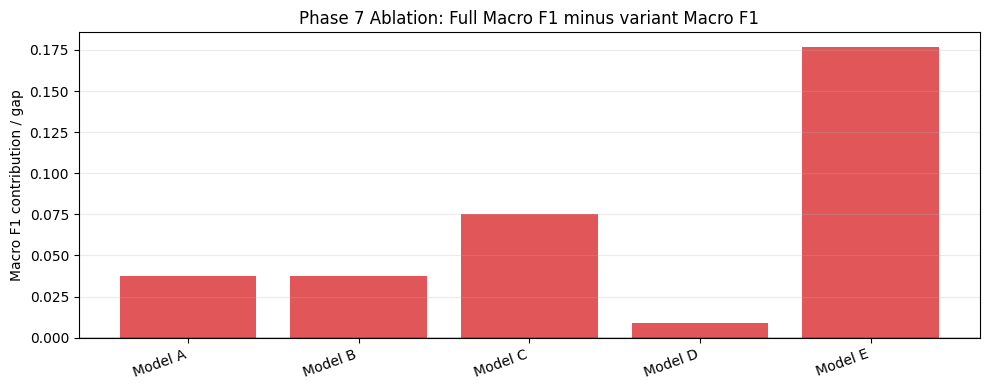

Saved ablation delta: /content/drive/MyDrive/BaoMatCuoiKy/Fake_reviews/reports/tables/phase7_ablation_delta.csv
Saved ablation figure: /content/drive/MyDrive/BaoMatCuoiKy/Fake_reviews/reports/figures/phase7_ablation_delta.png


In [14]:
# full_metric_row = ...: gán giá trị cho biến full metric row
full_metric_row = ablation_results_df[ablation_results_df["ablation_variant"].eq("Full Model")].iloc[0]
# delta_rows = ...: gán giá trị cho biến delta rows
delta_rows = []
# for: vòng lặp — for _, row in ablation_results_df.iterrows():
for _, row in ablation_results_df.iterrows():
    # delta_row = ...: gán giá trị cho biến delta row
    delta_row = {
        # "generated_at_utc": utc_now(),: thực thi lệnh Python
        "generated_at_utc": utc_now(),
        # "seed": SEED,: thực thi lệnh Python
        "seed": SEED,
        # "split": row.get("split", "test"),: thực thi lệnh Python
        "split": row.get("split", "test"),
        # "ablation_variant": row.get("ablation_variant"),: thực thi lệnh Python
        "ablation_variant": row.get("ablation_variant"),
        # "removed_component": row.get("removed_component"),: thực thi lệnh Python
        "removed_component": row.get("removed_component"),
        # "model_variant": row.get("model_variant"),: thực thi lệnh Python
        "model_variant": row.get("model_variant"),
        # "evidence_type": row.get("evidence_type"),: thực thi lệnh Python
        "evidence_type": row.get("evidence_type"),
        # "threshold": row.get("threshold"),: thực thi lệnh Python
        "threshold": row.get("threshold"),
        # "threshold_strategy": row.get("threshold_strategy"),: ép kiểu chuỗi
        "threshold_strategy": row.get("threshold_strategy"),
        # "notes": row.get("notes"),: thực thi lệnh Python
        "notes": row.get("notes"),
    # }: đóng khối từ điển
    }
    # for: vòng lặp — for metric in ["macro_f1", "precision_fake", "roc_auc", "pr_
    for metric in ["macro_f1", "precision_fake", "roc_auc", "pr_auc"]:
        # value = ...: ép kiểu số thực
        value = float(row.get(metric, np.nan)) if pd.notna(row.get(metric, np.nan)) else np.nan
        # full_value = ...: ép kiểu số thực
        full_value = float(full_metric_row.get(metric, np.nan))
        # delta_row[f"delta_{metric}"] = value - full_value if pd.notna(value) else np.nan: thực thi lệnh Python
        delta_row[f"delta_{metric}"] = value - full_value if pd.notna(value) else np.nan
        # delta_row[f"full_minus_variant_{metric}"] = full_value - value if pd.notna(value...: lấy giá trị nhỏ nhất
        delta_row[f"full_minus_variant_{metric}"] = full_value - value if pd.notna(value) else np.nan
    # delta_rows.append(delta_row): thực thi lệnh Python
    delta_rows.append(delta_row)

# ablation_delta_df = ...: gán giá trị cho biến ablation delta df
ablation_delta_df = pd.DataFrame(delta_rows)
# ablation_delta_path = ...: gán giá trị cho biến ablation delta path
ablation_delta_path = REPORT_TABLE_DIR / "phase7_ablation_delta.csv"
# ablation_delta_df.to_csv(ablation_delta_path, index=False): ghi DataFrame ra file CSV
ablation_delta_df.to_csv(ablation_delta_path, index=False)
# display(ablation_delta_df): hiển thị bảng/kết quả trên notebook
display(ablation_delta_df)

# plot_delta_df = ...: gán giá trị cho biến plot delta df
plot_delta_df = ablation_delta_df[ablation_delta_df["ablation_variant"].ne("Full Model")].copy()
# fig, ax = plt.subplots(figsize=(10, 4)): thực thi lệnh Python
fig, ax = plt.subplots(figsize=(10, 4))
# ax.bar(plot_delta_df["ablation_variant"], plot_delta_df["full_minus_variant_macr...: lấy giá trị nhỏ nhất
ax.bar(plot_delta_df["ablation_variant"], plot_delta_df["full_minus_variant_macro_f1"], color="#E15759")
# ax.axhline(0, color="black", linewidth=1): thực thi lệnh Python
ax.axhline(0, color="black", linewidth=1)
# ax.set_title("Phase 7 Ablation: Full Macro F1 minus variant Macro F1"): tạo tập hợp
ax.set_title("Phase 7 Ablation: Full Macro F1 minus variant Macro F1")
# ax.set_ylabel("Macro F1 contribution / gap"): tạo tập hợp
ax.set_ylabel("Macro F1 contribution / gap")
# ax.grid(axis="y", alpha=0.25): thực thi lệnh Python
ax.grid(axis="y", alpha=0.25)
# plt.xticks(rotation=20, ha="right"): thực thi lệnh Python
plt.xticks(rotation=20, ha="right")
# plt.tight_layout(): tự chỉnh lề biểu đồ
plt.tight_layout()
# ablation_delta_figure_path = ...: gán giá trị cho biến ablation delta figure path
ablation_delta_figure_path = REPORT_FIGURE_DIR / "phase7_ablation_delta.png"
# plt.savefig(ablation_delta_figure_path, dpi=160, bbox_inches="tight"): lưu biểu đồ ra file hình
plt.savefig(ablation_delta_figure_path, dpi=160, bbox_inches="tight")
# plt.show(): hiển thị biểu đồ
plt.show()
# print("Saved ablation delta:", ablation_delta_path): in thông tin ra console
print("Saved ablation delta:", ablation_delta_path)
# print("Saved ablation figure:", ablation_delta_figure_path): in thông tin ra console
print("Saved ablation figure:", ablation_delta_figure_path)


## 5. Error Analysis and Report Highlights

Error analysis exports false positives, false negatives, high-confidence errors, and borderline cases for both the default and Phase 5 selected threshold.

In [15]:
# load_test_context: hàm xử lý load test context
def load_test_context() -> pd.DataFrame:
    # context = ...: tạo dãy số cho vòng lặp
    context = pd.DataFrame({"test_row_index": np.arange(len(y["test"]), dtype=int)})
    # row_id_path = ...: gán giá trị cho biến row id path
    row_id_path = ROW_ID_PATHS["test"]
    # if: điều kiện — if row_id_path.exists():
    if row_id_path.exists():
        # row_ids = ...: đọc file CSV vào DataFrame
        row_ids = pd.read_csv(row_id_path)
        # row_ids = ...: tạo tập hợp
        row_ids = row_ids.reset_index().rename(columns={"index": "test_row_index"})
        # context = ...: ghép hai DataFrame
        context = context.merge(row_ids, on="test_row_index", how="left")
    # test_split_path = ...: gán giá trị cho biến test split path
    test_split_path = DATA_PROCESSED_DIR / "test.csv"
    # if: điều kiện — if test_split_path.exists():
    if test_split_path.exists():
        # test_df = ...: đọc file CSV vào DataFrame
        test_df = pd.read_csv(test_split_path, low_memory=False)
        # test_df = ...: tạo tập hợp
        test_df = test_df.reset_index().rename(columns={"index": "row_id"})
        # if: điều kiện — if "row_id" in context.columns:
        if "row_id" in context.columns:
            # keep_cols = ...: gán giá trị cho biến keep cols
            keep_cols = [col for col in ["row_id", "text", "title", "rating", "asin", "user_id", "timestamp", "label", "label_binary"] if col in test_df.columns]
            # context = ...: ghép hai DataFrame
            context = context.merge(test_df[keep_cols], on="row_id", how="left", suffixes=("", "_split"))
        # else: nhánh còn lại của điều kiện
        else:
            # keep_cols = ...: gán giá trị cho biến keep cols
            keep_cols = [col for col in ["text", "title", "rating", "asin", "user_id", "timestamp", "label", "label_binary"] if col in test_df.columns]
            # context = ...: nối nhiều DataFrame
            context = pd.concat([context, test_df[keep_cols].reset_index(drop=True)], axis=1)
        # if: điều kiện — if "text" in context.columns:
        if "text" in context.columns:
            # context["text_snippet"] = context["text"].astype(str).str.slice(0, 260): ép kiểu dữ liệu cột
            context["text_snippet"] = context["text"].astype(str).str.slice(0, 260)
            # context = ...: gán giá trị cho biến context
            context = context.drop(columns=["text"])
    # else: nhánh còn lại của điều kiện
    else:
        # PHASE7_FALLBACKS.append({"kind": "error_analysis_context", "reason": "data/proce...: thực thi lệnh Python
        PHASE7_FALLBACKS.append({"kind": "error_analysis_context", "reason": "data/processed/test.csv missing", "decision": "export row ids and probabilities only"})
    # return: trả kết quả từ hàm
    return context


# error_case_table: hàm xử lý error case table
def error_case_table(prob_fake: np.ndarray, threshold: float, strategy: str, top_n: int = 25) -> pd.DataFrame:
    # y_true = ...: gán giá trị cho biến y true
    y_true = y["test"]
    # pred = ...: ép kiểu dữ liệu cột
    pred = (prob_fake >= threshold).astype(int)
    # base = ...: gán giá trị cho biến base
    base = pd.DataFrame({
        # "test_row_index": np.arange(len(y_true), dtype=int),: tạo dãy số cho vòng lặp
        "test_row_index": np.arange(len(y_true), dtype=int),
        # "true_label": y_true.astype(int),: ép kiểu dữ liệu cột
        "true_label": y_true.astype(int),
        # "predicted_label": pred.astype(int),: dự đoán nhãn/xác suất
        "predicted_label": pred.astype(int),
        # "probability_fake": prob_fake.astype(float),: ép kiểu dữ liệu cột
        "probability_fake": prob_fake.astype(float),
        # "threshold": float(threshold),: ép kiểu số thực
        "threshold": float(threshold),
        # "threshold_strategy": strategy,: ép kiểu chuỗi
        "threshold_strategy": strategy,
    # }): đóng từ điển hoặc DataFrame constructor
    })
    # base["error_type"] = "correct": thực thi lệnh Python
    base["error_type"] = "correct"
    # base.loc[(base["true_label"].eq(REAL_LABEL)) & (base["predicted_label"].eq(FAKE_...: dự đoán nhãn/xác suất
    base.loc[(base["true_label"].eq(REAL_LABEL)) & (base["predicted_label"].eq(FAKE_LABEL)), "error_type"] = "false_positive_real_as_fake"
    # base.loc[(base["true_label"].eq(FAKE_LABEL)) & (base["predicted_label"].eq(REAL_...: dự đoán nhãn/xác suất
    base.loc[(base["true_label"].eq(FAKE_LABEL)) & (base["predicted_label"].eq(REAL_LABEL)), "error_type"] = "false_negative_fake_as_real"
    # base["confidence_wrong"] = np.where(: thực thi lệnh Python
    base["confidence_wrong"] = np.where(
        # base["error_type"].ne("correct"),: thực thi lệnh Python
        base["error_type"].ne("correct"),
        # np.where(base["predicted_label"].eq(FAKE_LABEL), base["probability_fake"], 1.0 -...: dự đoán nhãn/xác suất
        np.where(base["predicted_label"].eq(FAKE_LABEL), base["probability_fake"], 1.0 - base["probability_fake"]),
        # np.nan,: thực thi lệnh Python
        np.nan,
    # ): đóng ngoặc gọi hàm
    )
    # base["distance_to_threshold"] = (base["probability_fake"] - threshold).abs(): thực thi lệnh Python
    base["distance_to_threshold"] = (base["probability_fake"] - threshold).abs()
    # frames = ...: gán giá trị cho biến frames
    frames = []
    # for: vòng lặp — for case_name, selector, sort_cols, ascending in [
    for case_name, selector, sort_cols, ascending in [
        # ("false_positive_top", base["error_type"].eq("false_positive_real_as_fake"), ["p...: thực thi lệnh Python
        ("false_positive_top", base["error_type"].eq("false_positive_real_as_fake"), ["probability_fake"], [False]),
        # ("false_negative_top", base["error_type"].eq("false_negative_fake_as_real"), ["p...: thực thi lệnh Python
        ("false_negative_top", base["error_type"].eq("false_negative_fake_as_real"), ["probability_fake"], [True]),
        # ("highest_confidence_wrong", base["error_type"].ne("correct"), ["confidence_wron...: thực thi lệnh Python
        ("highest_confidence_wrong", base["error_type"].ne("correct"), ["confidence_wrong"], [False]),
        # ("borderline_near_threshold", pd.Series(True, index=base.index), ["distance_to_t...: thực thi lệnh Python
        ("borderline_near_threshold", pd.Series(True, index=base.index), ["distance_to_threshold"], [True]),
    # ]:: thực thi lệnh Python
    ]:
        # subset = ...: xem vài dòng đầu
        subset = base[selector].sort_values(sort_cols, ascending=ascending).head(top_n).copy()
        # subset["case_bucket"] = case_name: tạo tập hợp
        subset["case_bucket"] = case_name
        # frames.append(subset): tạo tập hợp
        frames.append(subset)
    # return: nối nhiều DataFrame
    return pd.concat(frames, ignore_index=True)


# context_df = ...: gán giá trị cho biến context df
context_df = load_test_context()
# error_default_df = ...: đếm số phần tử
error_default_df = error_case_table(probabilities["phase5_weighted_blend"]["test"], DEFAULT_THRESHOLD, "default_0.5")
# error_selected_df = ...: đếm số phần tử
error_selected_df = error_case_table(probabilities["phase5_weighted_blend"]["test"], selected_threshold, "phase5_selected_precision_threshold")
# error_analysis_df = ...: nối nhiều DataFrame
error_analysis_df = pd.concat([error_default_df, error_selected_df], ignore_index=True)
# error_analysis_df = ...: ghép hai DataFrame
error_analysis_df = error_analysis_df.merge(context_df, on="test_row_index", how="left")
# error_analysis_path = ...: gán giá trị cho biến error analysis path
error_analysis_path = REPORT_TABLE_DIR / "phase7_error_analysis.csv"
# error_analysis_df.to_csv(error_analysis_path, index=False): ghi DataFrame ra file CSV
error_analysis_df.to_csv(error_analysis_path, index=False)
# display(error_analysis_df.head(20)): hiển thị bảng/kết quả trên notebook
display(error_analysis_df.head(20))
# print("Saved error analysis:", error_analysis_path): in thông tin ra console
print("Saved error analysis:", error_analysis_path)


,test_row_index,true_label,predicted_label,probability_fake,threshold,threshold_strategy,error_type,confidence_wrong,distance_to_threshold,case_bucket,...,asin,timestamp,title,rating,asin_split,user_id_split,timestamp_split,label,label_binary,text_snippet
0,2169,0,1,0.987293,0.5,default_0.5,false_positive_real_as_fake,0.987293,0.487293,false_positive_top,...,B01CTQC9J2,1/24/2017 1:06,Ehh,2,B01CTQC9J2,AGUEFZUYXDUAC6DEFIHHMUAR3PEA,1/24/2017 1:06,0,0,Ehh
1,2058,0,1,0.985293,0.5,default_0.5,false_positive_real_as_fake,0.985293,0.485293,false_positive_top,...,B07LDDP5TV,10/17/2020 18:40,nice and thick and soft,4,B07LDDP5TV,AGRKZYDKMIYQSGCCFPNJENMTASFA,10/17/2020 18:40,0,0,looks great!
2,3609,0,1,0.984894,0.5,default_0.5,false_positive_real_as_fake,0.984894,0.484894,false_positive_top,...,B01LFO6IZK,12/7/2017 7:00,Three Stars,3,B01LFO6IZK,AFS37W3ZHLLPYEGY2R6HIT3ZAWAQ,12/7/2017 7:00,0,0,it's ok
3,2293,0,1,0.984426,0.5,default_0.5,false_positive_real_as_fake,0.984426,0.484426,false_positive_top,...,B079Y9LCXB,9/2/2018 20:26,100% effect,3,B079Y9LCXB,AGIQCNVVTMVEMYP5WGVBGNNZXVRA,9/2/2018 20:26,0,0,Excelent product
4,4060,0,1,0.983612,0.5,default_0.5,false_positive_real_as_fake,0.983612,0.483612,false_positive_top,...,B01GQLTYLC,12/18/2016 16:53,Two Stars,2,B01GQLTYLC,AEAK4M57EQ5CHHFMWXWPPDU7RU5Q,12/18/2016 16:53,0,0,arrived very dry
5,4185,0,1,0.979593,0.5,default_0.5,false_positive_real_as_fake,0.979593,0.479593,false_positive_top,...,B08P4QQXHL,5/15/2021 14:46,Too tight and painful,2,B08P4QQXHL,AEUOKK4ZERRZ7RXMND2QCNJ4UHJQ,5/15/2021 14:46,0,0,Too tight and painful
6,1621,0,1,0.979506,0.5,default_0.5,false_positive_real_as_fake,0.979506,0.479506,false_positive_top,...,B007BBW1WG,9/29/2016 3:33,Three Stars,3,B007BBW1WG,AGHPJVTDIS2GSXPYHL3IGL46TKPA,9/29/2016 3:33,0,0,Its an ok mask.
7,1535,0,1,0.977670,0.5,default_0.5,false_positive_real_as_fake,0.977670,0.477670,false_positive_top,...,B01MDTVZTZ,12/15/2022 18:46,Great product,4,B01MDTVZTZ,AF4ID4I76VMOPH7PCBFODAKK65KQ,12/15/2022 18:46,0,0,Pores are tightening
8,3992,0,1,0.977643,0.5,default_0.5,false_positive_real_as_fake,0.977643,0.477643,false_positive_top,...,B08TM1NJRD,4/18/2021 12:46,So-so,3,B08TM1NJRD,AEL26EZISWPJHAOQ2YI54CRVJREQ,4/18/2021 12:46,0,0,Expected more from the product
9,2370,0,1,0.974943,0.5,default_0.5,false_positive_real_as_fake,0.974943,0.474943,false_positive_top,...,B0184K0Y1M,6/9/2017 12:06,Three Stars,3,B0184K0Y1M,AHTJYSTDT4C4MDDDTGVWRWRQB74Q,6/9/2017 12:06,0,0,didn't fit my bottles.


Saved error analysis: /content/drive/MyDrive/BaoMatCuoiKy/Fake_reviews/reports/tables/phase7_error_analysis.csv


In [16]:
# highlight_rows = ...: gán giá trị cho biến highlight rows
highlight_rows = []
# for: vòng lặp — for strategy in ["default_0.5", "phase5_selected_precision_t
for strategy in ["default_0.5", "phase5_selected_precision_threshold"]:
    # row = ...: gán giá trị cho biến row
    row = final_metrics_df[
        # final_metrics_df["split"].eq("test"): thực thi lệnh Python
        final_metrics_df["split"].eq("test")
        # & final_metrics_df["model_variant"].eq("phase5_weighted_blend"): đếm số phần tử
        & final_metrics_df["model_variant"].eq("phase5_weighted_blend")
        # & final_metrics_df["threshold_strategy"].eq(strategy): ép kiểu chuỗi
        & final_metrics_df["threshold_strategy"].eq(strategy)
    # ].iloc[0]: thực thi lệnh Python
    ].iloc[0]
    # highlight_rows.append({: thực thi lệnh Python
    highlight_rows.append({
        # "section": "final_metrics",: thực thi lệnh Python
        "section": "final_metrics",
        # "item": f"phase5_weighted_blend_{strategy}",: đếm số phần tử
        "item": f"phase5_weighted_blend_{strategy}",
        # "metric_summary": f"macro_f1={row['macro_f1']:.4f}; precision_fake={row['precisi...: tính tổng
        "metric_summary": f"macro_f1={row['macro_f1']:.4f}; precision_fake={row['precision_fake']:.4f}; recall_fake={row['recall_fake']:.4f}; roc_auc={row['roc_auc']:.4f}",
        # "source_path": str(final_metrics_path),: ép kiểu chuỗi
        "source_path": str(final_metrics_path),
        # "notes": "Use default for balanced Macro F1; use selected threshold for high Pre...: ép kiểu chuỗi
        "notes": "Use default for balanced Macro F1; use selected threshold for high Precision Fake audit." if strategy != "default_0.5" else "Default threshold comparison row.",
    # }): đóng từ điển hoặc DataFrame constructor
    })

# missed_targets = ...: gán giá trị cho biến missed targets
missed_targets = target_audit_df[target_audit_df["pass"].eq(False)].copy()
# for: vòng lặp — for _, row in missed_targets.iterrows():
for _, row in missed_targets.iterrows():
    # highlight_rows.append({: thực thi lệnh Python
    highlight_rows.append({
        # "section": "target_audit",: thực thi lệnh Python
        "section": "target_audit",
        # "item": f"{row['threshold_strategy']}_{row['metric']}",: ép kiểu chuỗi
        "item": f"{row['threshold_strategy']}_{row['metric']}",
        # "metric_summary": f"actual={row['actual']:.4f}; target={row['target']:.4f}; gap=...: tính tổng
        "metric_summary": f"actual={row['actual']:.4f}; target={row['target']:.4f}; gap={row['gap_actual_minus_target']:.4f}",
        # "source_path": str(target_audit_path),: ép kiểu chuỗi
        "source_path": str(target_audit_path),
        # "notes": "Target missed; report explicitly.",: thực thi lệnh Python
        "notes": "Target missed; report explicitly.",
    # }): đóng từ điển hoặc DataFrame constructor
    })

# if: điều kiện — if not ablation_delta_df.empty:
if not ablation_delta_df.empty:
    # largest_macro_gap = ...: xem vài dòng đầu
    largest_macro_gap = ablation_delta_df[ablation_delta_df["ablation_variant"].ne("Full Model")].sort_values("full_minus_variant_macro_f1", ascending=False).head(1)
    # for: vòng lặp — for _, row in largest_macro_gap.iterrows():
    for _, row in largest_macro_gap.iterrows():
        # highlight_rows.append({: thực thi lệnh Python
        highlight_rows.append({
            # "section": "ablation",: thực thi lệnh Python
            "section": "ablation",
            # "item": f"largest_macro_f1_gap_{row['ablation_variant']}",: thực thi lệnh Python
            "item": f"largest_macro_f1_gap_{row['ablation_variant']}",
            # "metric_summary": f"full_minus_variant_macro_f1={row['full_minus_variant_macro_f...: tính tổng
            "metric_summary": f"full_minus_variant_macro_f1={row['full_minus_variant_macro_f1']:.4f}; evidence={row['evidence_type']}",
            # "source_path": str(ablation_delta_path),: ép kiểu chuỗi
            "source_path": str(ablation_delta_path),
            # "notes": str(row.get("notes", "")),: ép kiểu chuỗi
            "notes": str(row.get("notes", "")),
        # }): đóng từ điển hoặc DataFrame constructor
        })

# for: vòng lặp — for pointer_name, pointer_path in [
for pointer_name, pointer_path in [
    # ("phase6_final_shap_importance", PHASE6_FINAL_SHAP_IMPORTANCE_PATH),: thực thi lệnh Python
    ("phase6_final_shap_importance", PHASE6_FINAL_SHAP_IMPORTANCE_PATH),
    # ("phase6_final_lime_cases", PHASE6_FINAL_LIME_CASES_PATH),: thực thi lệnh Python
    ("phase6_final_lime_cases", PHASE6_FINAL_LIME_CASES_PATH),
    # ("phase6_robustness_metrics_legacy", PHASE6_ROBUSTNESS_PATH),: thực thi lệnh Python
    ("phase6_robustness_metrics_legacy", PHASE6_ROBUSTNESS_PATH),
    # ("phase6_shap_importance_legacy", PHASE6_SHAP_IMPORTANCE_PATH),: thực thi lệnh Python
    ("phase6_shap_importance_legacy", PHASE6_SHAP_IMPORTANCE_PATH),
    # ("phase6_lime_cases_legacy", PHASE6_LIME_CASES_PATH),: thực thi lệnh Python
    ("phase6_lime_cases_legacy", PHASE6_LIME_CASES_PATH),
# ]:: thực thi lệnh Python
]:
    # highlight_rows.append({: thực thi lệnh Python
    highlight_rows.append({
        # "section": "robustness_xai_pointer",: ép kiểu số nguyên
        "section": "robustness_xai_pointer",
        # "item": pointer_name,: ép kiểu số nguyên
        "item": pointer_name,
        # "metric_summary": "available" if pointer_path.exists() else "missing_optional",: kiểm tra file/thư mục tồn tại
        "metric_summary": "available" if pointer_path.exists() else "missing_optional",
        # "source_path": str(pointer_path),: ép kiểu số nguyên
        "source_path": str(pointer_path),
        # "notes": "Final-track XAI pointers are headline; legacy PCA rows are appendix-on...: xem vài dòng đầu
        "notes": "Final-track XAI pointers are headline; legacy PCA rows are appendix-only.",
    # }): đóng từ điển hoặc DataFrame constructor
    })

# report_highlights_df = ...: gán giá trị cho biến report highlights df
report_highlights_df = pd.DataFrame(highlight_rows)
# report_highlights_path = ...: gán giá trị cho biến report highlights path
report_highlights_path = REPORT_TABLE_DIR / "phase7_report_highlights.csv"
# report_highlights_df.to_csv(report_highlights_path, index=False): ghi DataFrame ra file CSV
report_highlights_df.to_csv(report_highlights_path, index=False)
# display(report_highlights_df): hiển thị bảng/kết quả trên notebook
display(report_highlights_df)
# print("Saved report highlights:", report_highlights_path): in thông tin ra console
print("Saved report highlights:", report_highlights_path)


,section,item,metric_summary,source_path,notes
0,final_metrics,phase5_weighted_blend_default_0.5,macro_f1=0.9433; precision_fake=0.9699; recall...,/content/drive/MyDrive/BaoMatCuoiKy/Fake_revie...,Default threshold comparison row.
1,final_metrics,phase5_weighted_blend_phase5_selected_precisio...,macro_f1=0.9126; precision_fake=0.9816; recall...,/content/drive/MyDrive/BaoMatCuoiKy/Fake_revie...,Use default for balanced Macro F1; use selecte...
2,target_audit,default_0.5_precision_fake,actual=0.9699; target=0.9750; gap=-0.0051,/content/drive/MyDrive/BaoMatCuoiKy/Fake_revie...,Target missed; report explicitly.
3,target_audit,phase5_balanced_macro_f1_threshold_precision_fake,actual=0.9344; target=0.9750; gap=-0.0406,/content/drive/MyDrive/BaoMatCuoiKy/Fake_revie...,Target missed; report explicitly.
4,ablation,largest_macro_f1_gap_Model E,full_minus_variant_macro_f1=0.1769; evidence=d...,/content/drive/MyDrive/BaoMatCuoiKy/Fake_revie...,Nearest available baseline from Phase 4; it re...
5,robustness_xai_pointer,phase6_final_shap_importance,available,/content/drive/MyDrive/BaoMatCuoiKy/Fake_revie...,Final-track XAI pointers are headline; legacy ...
6,robustness_xai_pointer,phase6_final_lime_cases,available,/content/drive/MyDrive/BaoMatCuoiKy/Fake_revie...,Final-track XAI pointers are headline; legacy ...
7,robustness_xai_pointer,phase6_robustness_metrics_legacy,available,/content/drive/MyDrive/BaoMatCuoiKy/Fake_revie...,Final-track XAI pointers are headline; legacy ...
8,robustness_xai_pointer,phase6_shap_importance_legacy,available,/content/drive/MyDrive/BaoMatCuoiKy/Fake_revie...,Final-track XAI pointers are headline; legacy ...
9,robustness_xai_pointer,phase6_lime_cases_legacy,available,/content/drive/MyDrive/BaoMatCuoiKy/Fake_revie...,Final-track XAI pointers are headline; legacy ...


Saved report highlights: /content/drive/MyDrive/BaoMatCuoiKy/Fake_reviews/reports/tables/phase7_report_highlights.csv


## 6. Metadata and Completion Checklist

The metadata below records seeds, source artifacts, output paths, fallback decisions, evidence types, and known limitations for reproducibility.

In [17]:
# phase7_output_paths = ...: gán giá trị cho biến phase7 output paths
phase7_output_paths = {
    # "input_validation": str(input_validation_path),: ép kiểu chuỗi
    "input_validation": str(input_validation_path),
    # "final_metrics": str(final_metrics_path),: ép kiểu chuỗi
    "final_metrics": str(final_metrics_path),
    # "target_audit": str(target_audit_path),: ép kiểu chuỗi
    "target_audit": str(target_audit_path),
    # "final_metrics_figure": str(final_metrics_figure_path),: ép kiểu chuỗi
    "final_metrics_figure": str(final_metrics_figure_path),
    # "target_gap_figure": str(target_gap_figure_path),: ép kiểu chuỗi
    "target_gap_figure": str(target_gap_figure_path),
    # "cv_metrics": str(cv_metrics_path),: ép kiểu chuỗi
    "cv_metrics": str(cv_metrics_path),
    # "cv_summary": str(cv_summary_path),: ép kiểu chuỗi
    "cv_summary": str(cv_summary_path),
    # "cv_summary_figure": str(cv_summary_figure_path) if cv_summary_figure_path else ...: ép kiểu chuỗi
    "cv_summary_figure": str(cv_summary_figure_path) if cv_summary_figure_path else None,
    # "ablation_results": str(ablation_results_path),: ép kiểu chuỗi
    "ablation_results": str(ablation_results_path),
    # "ablation_controlled_reference": str(reference_path) if reference_path else None...: ép kiểu chuỗi
    "ablation_controlled_reference": str(reference_path) if reference_path else None,
    # "ablation_delta": str(ablation_delta_path),: ép kiểu chuỗi
    "ablation_delta": str(ablation_delta_path),
    # "ablation_delta_figure": str(ablation_delta_figure_path),: ép kiểu chuỗi
    "ablation_delta_figure": str(ablation_delta_figure_path),
    # "error_analysis": str(error_analysis_path),: ép kiểu chuỗi
    "error_analysis": str(error_analysis_path),
    # "report_highlights": str(report_highlights_path),: ép kiểu chuỗi
    "report_highlights": str(report_highlights_path),
# }: đóng khối từ điển
}

# ablation_evidence_map = ...: gán giá trị cho biến ablation evidence map
ablation_evidence_map = (
    # ablation_results_df[["ablation_variant", "removed_component", "model_variant", "...: thực thi lệnh Python
    ablation_results_df[["ablation_variant", "removed_component", "model_variant", "evidence_type", "notes"]]
    # .fillna(""): điền giá trị thay thế cho NaN
    .fillna("")
    # .to_dict(orient="records"): tạo dictionary
    .to_dict(orient="records")
# ): đóng ngoặc gọi hàm
)

# phase7_metadata = ...: gán giá trị cho biến phase7 metadata
phase7_metadata = {
    # "generated_at_utc": utc_now(),: thực thi lệnh Python
    "generated_at_utc": utc_now(),
    # "seed": SEED,: thực thi lệnh Python
    "seed": SEED,
    # "project_root": str(PROJECT_ROOT),: ép kiểu chuỗi
    "project_root": str(PROJECT_ROOT),
    # "target_metrics": TARGET_METRICS,: thực thi lệnh Python
    "target_metrics": TARGET_METRICS,
    # "thresholds": {: thực thi lệnh Python
    "thresholds": {
        # "default_threshold": DEFAULT_THRESHOLD,: thực thi lệnh Python
        "default_threshold": DEFAULT_THRESHOLD,
        # "phase5_selected_threshold": selected_threshold,: thực thi lệnh Python
        "phase5_selected_threshold": selected_threshold,
        # "phase5_selected_candidate_name": selected_candidate_name,: thực thi lệnh Python
        "phase5_selected_candidate_name": selected_candidate_name,
        # "phase5_selected_candidate_config": selected_candidate_config,: thực thi lệnh Python
        "phase5_selected_candidate_config": selected_candidate_config,
    # },: đóng phần tử từ điển (còn phần tử sau)
    },
    # "source_artifacts": {: thực thi lệnh Python
    "source_artifacts": {
        # "phase2_metadata": str(PHASE2_METADATA_PATH),: ép kiểu chuỗi
        "phase2_metadata": str(PHASE2_METADATA_PATH),
        # "phase3_metadata": str(PHASE3_METADATA_PATH),: ép kiểu chuỗi
        "phase3_metadata": str(PHASE3_METADATA_PATH),
        # "phase4_metadata": str(PHASE4_METADATA_PATH),: ép kiểu chuỗi
        "phase4_metadata": str(PHASE4_METADATA_PATH),
        # "phase5_metadata": str(PHASE5_METADATA_PATH),: ép kiểu chuỗi
        "phase5_metadata": str(PHASE5_METADATA_PATH),
        # "phase6_metadata": str(PHASE6_METADATA_PATH),: ép kiểu chuỗi
        "phase6_metadata": str(PHASE6_METADATA_PATH),
        # "phase6_final_metadata": str(PHASE6_FINAL_METADATA_PATH),: ép kiểu chuỗi
        "phase6_final_metadata": str(PHASE6_FINAL_METADATA_PATH),
        # "pca_features": {split: str(path) for split, path in PCA_FEATURE_PATHS.items()},: ép kiểu chuỗi
        "pca_features": {split: str(path) for split, path in PCA_FEATURE_PATHS.items()},
        # "raw_features": {split: str(path) for split, path in RAW_FEATURE_PATHS.items()},: ép kiểu chuỗi
        "raw_features": {split: str(path) for split, path in RAW_FEATURE_PATHS.items()},
        # "probabilities": {model: {split: str(path) for split, path in paths.items()} for...: ép kiểu chuỗi
        "probabilities": {model: {split: str(path) for split, path in paths.items()} for model, paths in PROBABILITY_PATHS.items()},
    # },: đóng phần tử từ điển (còn phần tử sau)
    },
    # "cv": {: thực thi lệnh Python
    "cv": {
        # "folds": CV_FOLDS,: thực thi lệnh Python
        "folds": CV_FOLDS,
        # "cv_max_rows": CV_MAX_ROWS,: lấy giá trị lớn nhất
        "cv_max_rows": CV_MAX_ROWS,
        # "cv_mode": cv_mode,: thực thi lệnh Python
        "cv_mode": cv_mode,
        # "cv_reason": cv_reason,: thực thi lệnh Python
        "cv_reason": cv_reason,
        # "run_lightgbm": CV_RUN_LIGHTGBM,: thực thi lệnh Python
        "run_lightgbm": CV_RUN_LIGHTGBM,
        # "run_logistic_baseline": CV_RUN_LOGISTIC_BASELINE,: thực thi lệnh Python
        "run_logistic_baseline": CV_RUN_LOGISTIC_BASELINE,
    # },: đóng phần tử từ điển (còn phần tử sau)
    },
    # "controlled_ablation": {: thực thi lệnh Python
    "controlled_ablation": {
        # "run_controlled_ablation": RUN_CONTROLLED_ABLATIONS,: thực thi lệnh Python
        "run_controlled_ablation": RUN_CONTROLLED_ABLATIONS,
        # "controlled_ablation_max_rows": CONTROLLED_ABLATION_MAX_ROWS,: lấy giá trị lớn nhất
        "controlled_ablation_max_rows": CONTROLLED_ABLATION_MAX_ROWS,
        # "controlled_reduced_dim": CONTROLLED_ABLATION_REDUCED_DIM,: thực thi lệnh Python
        "controlled_reduced_dim": CONTROLLED_ABLATION_REDUCED_DIM,
        # "memory_limit_mb": CONTROLLED_MEMORY_LIMIT_MB,: thực thi lệnh Python
        "memory_limit_mb": CONTROLLED_MEMORY_LIMIT_MB,
    # },: đóng phần tử từ điển (còn phần tử sau)
    },
    # "ablation_evidence_map": ablation_evidence_map,: thực thi lệnh Python
    "ablation_evidence_map": ablation_evidence_map,
    # "fallback_decisions": PHASE7_FALLBACKS,: thực thi lệnh Python
    "fallback_decisions": PHASE7_FALLBACKS,
    # "known_limitations": [: thực thi lệnh Python
    "known_limitations": [
        # "Phase 7 does not rerun BERT extraction, PSO, or full deep model training.",: xóa biến để giải phóng RAM/VRAM
        "Phase 7 does not rerun BERT extraction, PSO, or full deep model training.",
        # "Model B and Model C are controlled LightGBM surrogate ablations, not full hybri...: xóa biến để giải phóng RAM/VRAM
        "Model B and Model C are controlled LightGBM surrogate ablations, not full hybrid retrains.",
        # "Model A is branch-level when the selected Phase 5 blend has zero DL weight.",: xóa biến để giải phóng RAM/VRAM
        "Model A is branch-level when the selected Phase 5 blend has zero DL weight.",
        # "Model E uses the nearest available Phase 4 baseline artifact; it should not be ...: xóa biến để giải phóng RAM/VRAM
        "Model E uses the nearest available Phase 4 baseline artifact; it should not be overclaimed as a full no-PCA/no-advanced-behavior retrain.",
        # "Re-run after 2026-06-09 Phase 5 pipeline; final_ensemble maps to phase5_weighte...: đếm số phần tử
        "Re-run after 2026-06-09 Phase 5 pipeline; final_ensemble maps to phase5_weighted_blend probabilities.",
    # ],: đóng phần tử danh sách (còn phần tử sau)
    ],
    # "outputs": phase7_output_paths,: thực thi lệnh Python
    "outputs": phase7_output_paths,
    # "environment": environment_versions(),: thực thi lệnh Python
    "environment": environment_versions(),
# }: đóng khối từ điển
}

# phase7_metadata_path = ...: gán giá trị cho biến phase7 metadata path
phase7_metadata_path = EVALUATION_DIR / "phase7_metadata.json"
# with: context manager — with phase7_metadata_path.open("w", encoding="utf-8") as fil
with phase7_metadata_path.open("w", encoding="utf-8") as file:
    # json.dump(phase7_metadata, file, indent=2): ghi dictionary ra JSON
    json.dump(phase7_metadata, file, indent=2)

# print("Saved Phase 7 metadata:", phase7_metadata_path): in thông tin ra console
print("Saved Phase 7 metadata:", phase7_metadata_path)
# print(json.dumps({"outputs": phase7_output_paths, "fallbacks": PHASE7_FALLBACKS}...: ghi dictionary ra JSON
print(json.dumps({"outputs": phase7_output_paths, "fallbacks": PHASE7_FALLBACKS}, indent=2))


Saved Phase 7 metadata: /content/drive/MyDrive/BaoMatCuoiKy/Fake_reviews/artifacts/evaluation/phase7_metadata.json
{
  "outputs": {
    "input_validation": "/content/drive/MyDrive/BaoMatCuoiKy/Fake_reviews/reports/tables/phase7_input_validation.csv",
    "final_metrics": "/content/drive/MyDrive/BaoMatCuoiKy/Fake_reviews/reports/tables/phase7_final_metrics.csv",
    "target_audit": "/content/drive/MyDrive/BaoMatCuoiKy/Fake_reviews/reports/tables/phase7_target_audit.csv",
    "final_metrics_figure": "/content/drive/MyDrive/BaoMatCuoiKy/Fake_reviews/reports/figures/phase7_final_metrics.png",
    "target_gap_figure": "/content/drive/MyDrive/BaoMatCuoiKy/Fake_reviews/reports/figures/phase7_target_gap.png",
    "cv_metrics": "/content/drive/MyDrive/BaoMatCuoiKy/Fake_reviews/reports/tables/phase7_cv_metrics.csv",
    "cv_summary": "/content/drive/MyDrive/BaoMatCuoiKy/Fake_reviews/reports/tables/phase7_cv_summary.csv",
    "cv_summary_figure": "/content/drive/MyDrive/BaoMatCuoiKy/Fake_reviews/

In [18]:
# MULTISEED_LIST: biến cấu hình/hằng số của notebook
MULTISEED_LIST = [42, 123, 456]
# MULTISEED_TARGET_PRECISION: biến cấu hình/hằng số của notebook
MULTISEED_TARGET_PRECISION = 0.975


# multiseed_prediction_dir: hàm xử lý multiseed prediction dir
def multiseed_prediction_dir(seed: int) -> Path:
    # if: điều kiện — if int(seed) == 42:
    if int(seed) == 42:
        # return: trả kết quả từ hàm
        return PREDICTION_DIR
    # return: trả kết quả từ hàm
    return PREDICTION_DIR / f"seed_{int(seed)}"


# load_multiseed_blend_probs: hàm xử lý load multiseed blend probs
def load_multiseed_blend_probs(seed: int):
    # pred_dir = ...: dự đoán nhãn/xác suất
    pred_dir = multiseed_prediction_dir(seed)
    # paths = ...: đếm số phần tử
    paths = {split: pred_dir / f"phase5_weighted_blend_{split}_prob.npy" for split in ["val", "test"]}
    # missing = ...: kiểm tra file/thư mục tồn tại
    missing = [str(path) for path in paths.values() if not path.exists()]
    # if: điều kiện — if missing:
    if missing:
        # return: trả kết quả từ hàm
        return None, missing
    # return: nạp mảng từ file .npy
    return {split: np.load(path).astype(np.float64) for split, path in paths.items()}, []


# select_multiseed_thresholds: hàm xử lý select multiseed thresholds
def select_multiseed_thresholds(y_val, prob_val):
    # balanced_tau = ...: ép kiểu số thực
    balanced_tau = float(DEFAULT_THRESHOLD)
    # precision_tau = ...: ép kiểu số thực
    precision_tau = float(DEFAULT_THRESHOLD)
    # best_balanced = ...: gán giá trị cho biến best balanced
    best_balanced = None
    # best_precision = ...: gán giá trị cho biến best precision
    best_precision = None
    # for: vòng lặp — for threshold in np.round(np.arange(0.01, 1.00, 0.01), 2):
    for threshold in np.round(np.arange(0.01, 1.00, 0.01), 2):
        # row = ...: gán giá trị cho biến row
        row = evaluate_probabilities(
            # y_val,: thực thi lệnh Python
            y_val,
            # prob_val,: thực thi lệnh Python
            prob_val,
            # split = ...: gán giá trị cho biến split
            split="val",
            # model_variant = ...: đếm số phần tử
            model_variant="phase5_weighted_blend",
            # threshold = ...: ép kiểu số thực
            threshold=float(threshold),
            # threshold_strategy = ...: ép kiểu chuỗi
            threshold_strategy="threshold_sweep",
        # ): đóng ngoặc gọi hàm
        )
        # if: điều kiện — if best_balanced is None or row["macro_f1"] > best_balanced[
        if best_balanced is None or row["macro_f1"] > best_balanced["macro_f1"]:
            # best_balanced = ...: gán giá trị cho biến best balanced
            best_balanced = row
            # balanced_tau = ...: ép kiểu số thực
            balanced_tau = float(threshold)
        # if: điều kiện — if row["precision_fake"] >= MULTISEED_TARGET_PRECISION:
        if row["precision_fake"] >= MULTISEED_TARGET_PRECISION:
            # if: điều kiện — if best_precision is None or (row["recall_fake"], row["macro
            if best_precision is None or (row["recall_fake"], row["macro_f1"]) > (
                # best_precision["recall_fake"],: thực thi lệnh Python
                best_precision["recall_fake"],
                # best_precision["macro_f1"],: thực thi lệnh Python
                best_precision["macro_f1"],
            # ):: thực thi lệnh Python
            ):
                # best_precision = ...: gán giá trị cho biến best precision
                best_precision = row
                # precision_tau = ...: ép kiểu số thực
                precision_tau = float(threshold)
    # return: trả kết quả từ hàm
    return balanced_tau, precision_tau


# y_val_ms = ...: gán giá trị cho biến y val ms
y_val_ms = load_labels("val")
# y_test_ms = ...: gán giá trị cho biến y test ms
y_test_ms = load_labels("test")
# multiseed_rows = ...: gán giá trị cho biến multiseed rows
multiseed_rows = []
# for: vòng lặp — for run_seed in MULTISEED_LIST:
for run_seed in MULTISEED_LIST:
    # prob_map, missing = load_multiseed_blend_probs(run_seed): đếm số phần tử
    prob_map, missing = load_multiseed_blend_probs(run_seed)
    # if: điều kiện — if prob_map is None:
    if prob_map is None:
        # print(f"Skipping seed {run_seed}; missing: {missing}"): in thông tin ra console
        print(f"Skipping seed {run_seed}; missing: {missing}")
        continue
    # balanced_tau, precision_tau = select_multiseed_thresholds(y_val_ms, prob_map["va...: thực thi lệnh Python
    balanced_tau, precision_tau = select_multiseed_thresholds(y_val_ms, prob_map["val"])
    # mode_specs = ...: gán giá trị cho biến mode specs
    mode_specs = [
        # ("balanced", balanced_tau, "phase5_balanced_macro_f1_threshold"),: thực thi lệnh Python
        ("balanced", balanced_tau, "phase5_balanced_macro_f1_threshold"),
        # ("precision_first", precision_tau, "phase5_selected_precision_threshold"),: thực thi lệnh Python
        ("precision_first", precision_tau, "phase5_selected_precision_threshold"),
    # ]: đóng khối danh sách
    ]
    # for: vòng lặp — for mode_name, threshold, strategy in mode_specs:
    for mode_name, threshold, strategy in mode_specs:
        # row = ...: gán giá trị cho biến row
        row = evaluate_probabilities(
            # y_test_ms,: thực thi lệnh Python
            y_test_ms,
            # prob_map["test"],: thực thi lệnh Python
            prob_map["test"],
            # split = ...: gán giá trị cho biến split
            split="test",
            # model_variant = ...: đếm số phần tử
            model_variant="phase5_weighted_blend",
            # threshold = ...: gán giá trị cho biến threshold
            threshold=threshold,
            # threshold_strategy = ...: ép kiểu chuỗi
            threshold_strategy=strategy,
        # ): đóng ngoặc gọi hàm
        )
        # row["run_seed"] = int(run_seed): ép kiểu số nguyên
        row["run_seed"] = int(run_seed)
        # row["mode"] = mode_name: thực thi lệnh Python
        row["mode"] = mode_name
        # multiseed_rows.append(row): thực thi lệnh Python
        multiseed_rows.append(row)

# multiseed_metrics_df = ...: gán giá trị cho biến multiseed metrics df
multiseed_metrics_df = pd.DataFrame(multiseed_rows)
# multiseed_summary_rows = ...: tính tổng
multiseed_summary_rows = []
# for: vòng lặp — for mode_name in ["balanced", "precision_first"]:
for mode_name in ["balanced", "precision_first"]:
    # subset = ...: tạo tập hợp
    subset = multiseed_metrics_df[multiseed_metrics_df["mode"].eq(mode_name)]
    # if: điều kiện — if subset.empty:
    if subset.empty:
        continue
    # for: vòng lặp — for metric_name in ["macro_f1", "precision_fake", "recall_fa
    for metric_name in ["macro_f1", "precision_fake", "recall_fake", "roc_auc"]:
        # multiseed_summary_rows.append(: tính tổng
        multiseed_summary_rows.append(
            # {: thực thi lệnh Python
            {
                # "mode": mode_name,: thực thi lệnh Python
                "mode": mode_name,
                # "metric": metric_name,: thực thi lệnh Python
                "metric": metric_name,
                # "n_seeds": int(len(subset)),: đếm số phần tử
                "n_seeds": int(len(subset)),
                # "mean": float(subset[metric_name].mean()),: ép kiểu số thực
                "mean": float(subset[metric_name].mean()),
                # "std": float(subset[metric_name].std(ddof=0)),: ép kiểu số thực
                "std": float(subset[metric_name].std(ddof=0)),
                # "min": float(subset[metric_name].min()),: ép kiểu số thực
                "min": float(subset[metric_name].min()),
                # "max": float(subset[metric_name].max()),: ép kiểu số thực
                "max": float(subset[metric_name].max()),
            # }: đóng khối từ điển
            }
        # ): đóng ngoặc gọi hàm
        )

# multiseed_summary_df = ...: tính tổng
multiseed_summary_df = pd.DataFrame(multiseed_summary_rows)
# multiseed_metrics_path = ...: gán giá trị cho biến multiseed metrics path
multiseed_metrics_path = REPORT_TABLE_DIR / "phase7_multiseed_metrics.csv"
# multiseed_summary_path = ...: tính tổng
multiseed_summary_path = REPORT_TABLE_DIR / "phase7_multiseed_summary.csv"
# multiseed_metrics_df.to_csv(multiseed_metrics_path, index=False): ghi DataFrame ra file CSV
multiseed_metrics_df.to_csv(multiseed_metrics_path, index=False)
# multiseed_summary_df.to_csv(multiseed_summary_path, index=False): ghi DataFrame ra file CSV
multiseed_summary_df.to_csv(multiseed_summary_path, index=False)
# display(multiseed_summary_df): hiển thị bảng/kết quả trên notebook
display(multiseed_summary_df)
# print("Saved multi-seed tables:", multiseed_metrics_path, multiseed_summary_path...: in thông tin ra console
print("Saved multi-seed tables:", multiseed_metrics_path, multiseed_summary_path)


,mode,metric,n_seeds,mean,std,min,max
0,balanced,macro_f1,3,0.948466,0.001777,0.946019,0.950184
1,balanced,precision_fake,3,0.950577,0.006676,0.942769,0.959078
2,balanced,recall_fake,3,0.926956,0.005059,0.919970,0.931784
3,balanced,roc_auc,3,0.976410,0.000486,0.975747,0.976900
4,precision_first,macro_f1,3,0.920270,0.006560,0.914767,0.929490
5,precision_first,precision_fake,3,0.976311,0.002941,0.972792,0.979991
6,precision_first,recall_fake,3,0.836763,0.015450,0.821265,0.857851
7,precision_first,roc_auc,3,0.976410,0.000486,0.975747,0.976900


Saved multi-seed tables: /content/drive/MyDrive/BaoMatCuoiKy/Fake_reviews/reports/tables/phase7_multiseed_metrics.csv /content/drive/MyDrive/BaoMatCuoiKy/Fake_reviews/reports/tables/phase7_multiseed_summary.csv


## Phase 7 Checklist

- [x] EVAL-01: Final metrics include Macro F1, Precision Fake, Recall Fake, F1 Fake, ROC-AUC, PR-AUC, Brier score, and confusion matrix values.
- [x] EVAL-02: 5-fold CV is implemented with a resource-aware fallback.
- [x] EVAL-03: Ablation variants Full, Model A, Model B, Model C, Model D, and Model E are exported with evidence-type labels.
- [x] EVAL-04: Metrics tables, target audit, ablation tables, and figures are exported for the report.
- [x] EVAL-05: Metadata records seed, splits, thresholds, source artifacts, configs, fallbacks, and environment versions.

Report note: target misses are not hidden. Use `phase7_target_audit.csv` and `phase7_report_highlights.csv` directly in Phase 8.
- [x] EVAL-06: Multi-seed stability summary exported to `phase7_multiseed_summary.csv` when Phase 5 seed artifacts exist.
